# Homework 6
## Heat and Moisture Transport in a Soil Column 
Models of vertical transfer of heat and moisture (liquid water only) in a soil column are provided in this homework. Additionally, code to calculate various parameterizations of heat and moisture transfer as a function of soil parameters are included. We will explore several scenarios and see how their solution varies depending on the selection of parameters, and choices of parameterizations.<br>

A table of soil texture data, as used in the Noah-MP LSM, is provided:
* NoahMP_soil_texture_table.csv 


In [1]:
import sys
import pandas as pd
import numpy as np
from scipy.linalg import solve_banded

import matplotlib.pyplot as plt
#import seaborn as sns

import warnings
#warnings.filterwarnings('once', category=UserWarning)

### Hydraulic Pedotransfer Functions

We will examine the two most common pedotransfer formulations:

#### The Clapp & Hornberger parameterization:
There are many ways to calculate $\psi$ and $k$. One of the earlierst commonly used in land surface models, often derided, is the *Clapp & Hornberger* [1978] parameterization:

$$
\quad \psi_i=\psi_{sat}w_i^{-B}, \quad k_{i+\frac{1}{2}}=k_{sat}\bigg(\dfrac{w_i+w_{i+1}}{2}\bigg)^{(2B+3)/B}
, \;\;\;\; w = \dfrac{\theta}{\theta_s}
$$


This parameterization is based on lab measurements published by Brooks and Corey (1964).

> Clapp, R.B. and G. M. Hornberger, 1978: Empirical equations for some soil hydraulic properties. <i>Water Resour. Res.</i>, <b>14</b>, 601–604, [doi:10.1029/WR014i004p00601](https://doi.org/10.1029/WR014i004p00601).

> Brooks, R.H. and A.T. Corey, 1964: Hydraulic Properties of Porous Media. <i>Hydrology Paper, Vol. 3</i>, Colorado State University, Fort Collins, CO, USA.

#### van Genuchten's parameterization:
The formulation for matric potential of *van Genuchten* [1980] is considered more accurate:

$$
\quad \psi_i = \dfrac{1}{a}\bigg(\dfrac{1}{u_i^{1/m}}-1\bigg)^{1-m}, \;\;\;\; u = \dfrac{\theta-\theta_{res}}{\theta_s-\theta_{res}}
$$


The complementary formulation for conductivity is from *Mualem* [1976]:

$$
\quad k_{i+\frac{1}{2}} = k_{sat}u_i^{1/2}\big[1-(1-u_i^{1/m})^m\big]^2
$$

> van Genuchten, M. T., 1980: A closed form equation for predicting the hydraulic conductivity of unsaturated soils. <i>Soil Sci. Soc. Amer.</i>, <b>44</b>, 892–898, [doi:10.2136/sssaj1980.03615995004400050002x](https://doi.org/10.2136/sssaj1980.03615995004400050002x).

> Maulem, Y., 1976: A new model for predicting the hydraulic conductivity of unsaturated porous media. <i>Water Resour. Res.</i>, <b>12</b>, 513-522, [doi:10.1029/WR012i003p00513](https://doi.org/10.1029/WR012i003p00513).

### Soil Heat Functions

We will also look at some common formulations for determining thermal properties of the soil:

#### The McCumber and Pielke parameterization for thermal conductivity:
Thermal conductivity of soils based solely on matric potential was derived by McCumber & Pielke (1981) following a highly empirical formulation:

$$
k_{i+\frac{1}{2}} = \exp ({2.7-\log_{10}\psi_{i+\frac{1}{2}}}),  \;\;\;\; \log_{10}\psi_{i+\frac{1}{2}} ≤ 5.1
$$
$$
k_{i+\frac{1}{2}} = 4.1 \times 10^{-4},                    \;\;\;\; \log_{10}\psi_{i+\frac{1}{2}} > 5.1
$$

> McCumber, M. C., and R. A. Pielke, 1981: Simulation of the effects of surface fluxes of heat and moisture in a mesoscale numerical model: 1. Soil layer. <i>Journal of Geophysical Research,</i> <b>86</b>, 9929–9938, [doi:10.1029/JC086iC10p09929](https://doi.org/10.1029/JC086iC10p09929).

#### The Johansen parameterization for thermal conductiviy:
Calculates soil thermal conductivity using the Johansen (1975) formulation, which is based on soil water content rather than matric potential:
    
$$
k_{i+\frac{1}{2}} =  K_e (k_{sat} − k_{dry}) + k_{dry}
$$
where:
$$
k_{sat} = k_{soil}^{1−\theta_{sat}} k_{ice}^{\theta f_{ice}} k_{water}^{\theta (1-f_ice)}
$$
and:
$$
k_{dry} = \frac{0.135\gamma_{d} + 64.7}{2700−0.947\gamma_{d}}
$$
$$
\gamma_d = 2700(1 − \theta_{sat})
$$

$K_e$ is the "Kersten number":

$$
\begin{array}{l l}
K_e = 0.7 \ln(\theta / \theta_{sat}) + 1.0  & \textsf{for coarse soils where  } \theta / \theta_{sat} > 0.05\\
K_e = \ln(\theta / \theta_{sat}) + 1.0     & \textsf{for fine soils where  } \theta / \theta_{sat} > 0.1\\
K_e = \theta / \theta_{sat}               & \textsf{for frozen soils}
\end{array}
$$
  
Thermal conductivity is defined across the interface at the top of each layer. 
Values of $\theta$ are weighted averages at the interfaces.

> Johansen, O., 1975: Thermal conductivity of soils. Ph.D. dissertation, Norwegian University of Science and Technology, 291 pp.

### The de Vries heat capacity parameterization
Calculates volumetric soil heat capacity using de Vries (1963) formulation:
    
$$
c_i = (1-\theta_{sat})c_{soil} + \theta(1-f_{ice})c_{water} + \theta f_{ice} c_{ice}  
$$    

Soil heat capacity is defined by volume for each layer

> DeVries D.A., 1963: Thermal Properties of Soils. In W.R. van Wijk (ed.) <i>Physics of Plant Environment</i>, North-Holland Publishing Company, Amsterdam.

------------------

**The large code cell below contains functions for the soil model.**

In [2]:
def clapp_hornberger_psi(theta,theta_sat,psi_sat,b):
    """
    Calculates matric potential using Clapp & Hornberger (1978) formulation:
    
    ψ_i = ψ_sat * (w_i)^(-B)
    
    w_i = θ_i / θ_sat
    
        Matric potential, in units of hydraulic head, is defined within each soil layer
    
    Required inputs:
        theta              (array) = Volumetric soil moisture [m^3/m^3] in each layer of column (top to bottom)
        theta_sat (float or array) = Soil porosity [m^3/m^3] (in each layer or a single value for all layers)
        psi_sat   (array or float) = Saturated matric potential [m] (in each layer or a single value for all layers)
        b                  (float) = "b" parameter [-]
        
    Outputs:
        psi                (array) = Matric potential [m] in each layer of soil column (top to bottom)
        dpsi_dtheta        (array) = Derivative w.r.t. VSM in each layer of soil column (top to bottom)
    """    
    theta0 = np.where(theta < 0.001, 0.001, theta)  # Prevent blow-up at dessication
    #theta0 = theta
    w = theta0 / theta_sat                        # Soil wetness: 0=dry, 1=saturated (i.e. at porosity)
    psi = psi_sat*w**(-b)
    dpsi_dtheta = -b*psi/w
    
    return psi,dpsi_dtheta


def clapp_hornberger_k(theta,theta_sat,k_sat,b):
    """
    Calculates hydraulic conductivity using Clapp & Hornberger (1978) formulation:
    
    k_(i+½) = k_sat * ((w_i+w_(i+1))/2)^((2B+3)/B)

    w_i = θ_i / θ_sat

        Hydraulic conductivity is defined across the interface at the bottom of the top N-1 layers
    
    Required inputs:
        theta              (array) = Volumetric soil moisture [m^3/m^3] in each layer of column (top to bottom)
        theta_sat (float or array) = Soil porosity [m^3/m^3] (in each layer or a single value for all layers)
        k_sat     (array or float) = Saturated hydraulic conductivity [m/s](in each layer or a single value for all layers)
        b                  (float) = "b" parameter [-]
        
    Output:
        k                  (array) = Hydraulic conductivity [m/s] at the bottom of each layer of soil column (top to bottom)  
    """
    k_min = 1.e-10                                # Set a minumum value for numerical stability
    w = theta / theta_sat                         # Soil wetness: 0=dry, 1=saturated (i.e. at porosity)
    w_half = (w[:-1]+w[1:])*0.5                   # Simple soil wetness theta at each interface
    
    if hasattr(k_sat, "__len__"):      # If there is vertical structure in k_sat
        k_half = np.exp((np.log(k_sat[:-1])+np.log(k_sat[1:]))*0.5)
    else:
        k_half = k_half
    if hasattr(b, "__len__"):         # If there is vertical structure in b
        b_half = (b[:-1]+b[1:])*0.5
    else:
        b_half = b
    
    #k = k_sat*(w_half)**((2.0*b+3.0)/b)           # Sellers 1986 version
    k = k_half*(w_half)**((2.0*b_half+3.0))             # Original version
    #k = np.where(k > k_min, k, k_min)             # Apply minimum limit

    return k


def clapp_hornberger_theta(theta_sat,psi,psi_sat,b):
    """
    Calculates volumetric soil moisture from the matric potential using the Clapp & Hornberger formulation:
    
    θ_i = (ψ_i/ψ_sat)^(-1/B) * θ_sat
    
        Volumetric soil mositure is defined within each soil layer
    
    Required inputs:
        theta_sat (float or array) = Soil porosity [m^3/m^3] (in each layer or a single value for all layers)
        psi                (array) = Matric potential in each layer of soil column (top to bottom)
        psi_sat   (array or float) = Saturated matric potential [m] (in each layer or a single value for all layers)
        b                  (float) = "b" parameter [-] (soil property)
        
    Output:
        theta              (array) = Volumetric soil moisture [m^3/m^3] in each layer of column (top to bottom)
    """    
    theta = (psi/psi_sat)**(-1/b) * theta_sat
    
    return theta


def van_genuchten_psi(theta,theta_sat,theta_res,m,a):
    """
    Calculates matric potential using the van Genuchten (1980) formulation:
    
    ψ_i = (1/((u_i)^(1/m)) - 1)^(1-m) / a

    u_i = (θ_i - θ_res) / (θ_sat - θ_res)

        Matric potential, in units of hydraulic head, is defined within each soil layer
    
    Required inputs:
        theta              (array) = Volumetric soil moisture [m^3/m^3] in each layer of column (top to bottom)
        theta_sat (float or array) = Soil porosity [m^3/m^3] (in each layer or a single value for all layers)
        theta_res (array or float) = Residual theta, epirically determined and defined as a function of soil type
        m         (array or float) = Pore size distribution index [-] (soil property)
        a         (array or float) = Inverse of air entry potential [1/m] (soil property)
        
    Output:
        psi                (array) = Matric potential [m] in each layer of soil column (top to bottom)
        dpsi_dtheta        (array) = Derivative w.r.t. VSM in each layer of soil column (top to bottom)
    """    
    
    u = (theta-theta_res)/(theta_sat-theta_res)
    #u0 = np.where(u > 0.995, 0.995, np.where(u < 0.01, 0.01, u))  # Prevent blow-up at extremes
    u0 = np.where(u > 0.995, 0.995, u)
    #u0 = u

    psi = -((1/(u0**(1/m))-1)**(1-m))/a
    dpsi_dtheta = ((1-m)*u0**-(1+1/m)) / (a*m*(1/(u0**(1/m))-1)**m)
    
    return psi,dpsi_dtheta


def mualem_k(theta,theta_sat,theta_res,k_sat,m):
    """
    Calculates hydraulic conductivity using the Mualem (1976) formulation (consistent with 'm' parameter of Van Genuchten):
    
    k_(i+½) = k_sat * u_i+½^(1/2) * (1 - (1 - u_i+½^(1/m))^m)^2
    
        Hydraulic conductivity is defined across the interface at the bottom of each layer
    
    Required inputs:
        theta              (array) = Volumetric soil moisture normalized by porosity in each layer of column (top to bottom)
        theta_sat (float or array) = Soil porosity [m^3/m^3] (in each layer or a single value for all layers)
        theta_res (array or float) = Residual theta, epirically determined and defined as a function of soil type
        k_sat     (array or float) = Saturated hydraulic conductivity [m/s] (in each layer or a single value for all layers)
        m         (array or float) = Pore size distribution index [-] (soil property)
        
    Outputs:
        k                (array) = Hydraulic conductivity [m/s] at the bottom of each layer of soil column (top to bottom)  
    """
    k_min = 1.e-28            # Set a minumum value for numerical stability
    u = (theta-theta_res)/(theta_sat-theta_res)
    #u0 = np.where(u > 0.99, 0.99, np.where(u < 0.01, 0.01, u))  # Prevent blow-up at extremes
    u0 = u
    u_half = (u0[:-1]+u0[1:])*0.5       # Simple average theta at each interface

    if hasattr(k_sat, "__len__"):      # If there is vertical structure in k_sat
        k_half = np.exp((np.log(k_sat[:-1])+np.log(k_sat[1:]))*0.5)
    else:
        k_half = k_half
    if hasattr(m, "__len__"):         # If there is vertical structure in b
        m_half = (m[:-1]+m[1:])*0.5
    else:
        m_half = m
       
    k = k_half * np.sqrt(u_half) * (1-(1-(u_half)**(1/m_half))**m_half)**2
    #k = np.where(k > k_min, k, k_min)             # Apply minimum limit

    return k


def van_genuchten_theta(theta_sat,theta_res,psi,m,a):
    """
    Calculates volumetric soil moisture from the matric potential using the van Genuchten (1980) formulation:
    
    u_i = (1 + (a*ψ_i)^(1/(1-m))^-m
    
        Volumetric soil mositure is defined within each soil layer
    
    Required inputs:
        theta_sat (float or array) = Soil porosity [m^3/m^3] (in each layer or a single value for all layers)
        theta_res (array or float) = Residual theta, epirically determined and defined as a function of soil type
        psi                (array) = Matric potential [m] in each layer of soil column (top to bottom)
        m         (array or float) = Pore size distribution index [-] (soil property)
        a         (array or float) = Inverse of air entry potential [1/m] (soil property)
        
    Output:
        theta              (array) = Volumetric soil moisture normalized by porosity in each layer of column (top to bottom)
    """    
    u = (1+(a*abs(psi))**(1/(1-m)))**-m
    
    theta = u*(theta_sat-theta_res) + theta_res

    return theta

def sib_baseflow(slope,k_bottom):
    """
    Returns baseflow [m/s] as function of terrain slope and hydraulic conductivity of lowest soil layer
    
    Required inputs:
        slope     (float) = Average terrain slope [radians]
        k_bottom  (float) = Hydraulic conductivity [m/s] of lowest soil layer
    
    Output:
        baseflow  (float) = Flux of water out of bottom of soil column [m/s]
    """
    baseflow = np.sin(slope)*k_bottom
    
    return baseflow 


#====================================================================================================================


def mccumber_pielke_kt(psi,thick):
    """
    Calculates thermal conductivity using McCumber & Pielke (1981) formulation:
    
    k_(i+½) = exp(-log10(ψ_(i+½))+2.7)  for log10(ψ_(i+½)) ≤ 5.1
    k_(i+½) = 4.1e-4                    for log10(ψ_(i+½)) > 5.1
    
        This formula is for units of k of [cal/s/cm/K] ... *4.186/100 to get W/m/K
        ψ in this formulation must be in [cm]
        Thermal conductivity is defined across the interface at the top of each layer
    
    Required inputs:
        psi              (array) = Matric potential [m] in each layer of soil column (top to bottom)
        thick            (array) = Thickness [m] of each layer of column (top to bottom)
        
    Outputs:
        k                (array) = Thermal conductivity [W/m/K] at the top of each layer of soil column (top to bottom)  
    """
    log_max = 5.1
    m = thick * psi                                         # Depth times psi [m^2]
    p = (m[:-1]+m[1:])/(thick[:-1]+thick[1:])               # Depth-weighted average psi at each interface [m]
    p = np.append(psi[0],p) * 100                           # Set top interface equal to first layer. convert [m] to [cm]
    
    lp = np.log10(p)
    k = np.exp(-(lp+2.7))
    k = np.where(lp <= log_max, k, 4.1e-4)*4186*0.01*10      # Apply minximum limit, convert [kcal]/[cm] to [J/m]
                                                            # There is an extra factor of 10 needed to match results of
                                                            #     Peters-Lidard et al (1998) - units error??

    return k


def johansen_kt(w,w_sat,thick,sand_frac,ice_frac=0.0):
    """
    Calculates thermal conductivity using the Johansen (1975) formulation:
    
    k_(i+½) = K_e (k_sat − k_dry) + k_dry
            where:
              k_sat = k_soil^(1−θ_sat) k_ice^(θ*f_ice) k_water^(θ(1-f_ice))
              k_dry = (0.135γ_d + 64.7)/(2700−0.947γ_d)
              γ_d = 2700(1 − θ_sat)
            and K_e is the "Kersten number":
              K_e = 0.7ln(θ/θ_sat) + 1.0  for θ/θ_sat > 0.05 (Coarse soils)
              K_e = ln(θ/θ_sat) + 1.0     for θ/θ_sat > 0.1 (Fine soils)
              K_e = θ/θ_sat               for frozen soils
     
        Thermal conductivity is defined across the interface at the top of each layer. Values
            of θ are weighted averages at the interfaces.
    
    Required inputs:
        w                  (array) = Volumetric soil moisture [m^3/m^3] in each layer of column (top to bottom)
        w_sat     (array or float) = Soil porosity [m^3/m^3] (in each layer or a single value for all layers)
        thick              (array) = Thickness [m] of each layer of column (top to bottom)
        sand_frac (array or float) = fraction of soil layer composed of sand
        
    Optional inputs:
        ice_frac  (array or float) = fraction of water [-] in each soil layer that is frozen

    Outputs:
        k                  (array) = Thermal conductivity [W/m/K] at the top of each layer of soil column (top to bottom)  
    """
    # Set up constants
    k_ice = 2.29              # [W/m/K]
    k_water = 0.57            # [W/m/K]
    k_sand = 7.7              # [W/m/K] Applied to quartz fraction following Farouki (1981)
    k_other = 2.0             # [W/m/K]
    fine_threshold = 0.5      # Fraction of sand separating coarse and fine soils

    # Get porosity at each layer interface
    p = thick * w_sat+w-w                                  # porosity in each layer * depth [m]; making sure it's an array
    p_weighted = (p[:-1]+p[1:])/(thick[:-1]+thick[1:])     # Depth-weighted average porosity at each interface
    p_weighted = np.append(p[0]/thick[0],p_weighted)       # Set top interface equal to first layer value

    # Get SWI at each layer interface with minimums required for Kersten number calculation
    m = thick * w/w_sat                                    # SMI in each layer * depth [m] or [1000 kg / m^2]
    if hasattr(sand_frac, "__len__"):                      # Not a scalar; values at each level
        m = np.where(sand_frac < fine_threshold,
                     np.where(w/w_sat > 0.1, m, thick * 0.1),
                     np.where(w/w_sat > 0.05, m, thick * 0.05))  
    else:
        if sand_frac < fine_threshold:
            m = np.where(w/w_sat > 0.1, m, thick * 0.1)
        else:
            m = np.where(w/w_sat > 0.05, m, thick * 0.05)
    w_weighted = (m[:-1]+m[1:])/(thick[:-1]+thick[1:])     # Depth-weighted average SMI at each interface
    w_weighted = np.append(m[0]/thick[0],w_weighted)       # Set top interface equal to first layer value

    # Get frozen SWI at each layer interface
    f = m * ice_frac                                       # Ice in each layer [m] or [1000 kg / m^2]
    f_weighted = (f[:-1]+f[1:])/(thick[:-1]+thick[1:])     # Depth-weighted average ice at each interface
    f_weighted = np.append(f[0]/thick[0],f_weighted)       # Set top interface equal to first layer value

    # Find dry soil conductivities
    gamma_d = 2700.0 * (1.0 - w_sat)
    k_dry = (0.135*gamma_d + 64.7) / (2700.0 - 0.947*gamma_d)
    
    # Find Kersten number(s)
    if hasattr(sand_frac, "__len__"):                      # Not a scalar; values at each level
        s = thick * sand_frac            
        s_weighted = (s[:-1]+s[1:])/(thick[:-1]+thick[1:])     # Depth-weighted sand fraction at each interface
        s_weighted = np.append(sand_frac[0],s_weighted)   # Set top interface equal to first layer value
        
        kersten = np.where(sand_frac < fine_threshold,
                           (np.log10(w_weighted) + 1.0) * (1.0-f_weighted/w_weighted) + f_weighted,
                           (0.7*np.log10(w_weighted) + 1.0) * (1.0-f_weighted/w_weighted) + f_weighted) 
    else:
        if sand_frac < fine_threshold:
            kersten = (np.log10(w_weighted) + 1.0) * (1.0-f_weighted/w_weighted) + f_weighted
        else:
            kersten = (0.7*np.log10(w_weighted) + 1.0) * (1.0-f_weighted/w_weighted) + f_weighted
    
    # Find saturated soil conductivities
    k_soil = k_sand * sand_frac + k_other * (1.0-sand_frac) # Weigthed average by quartz content
    k_sat = k_soil**(1.0-w_sat) * k_ice**(w_weighted*w_sat*ice_frac) * k_water**(w_weighted*w_sat*(1.0-ice_frac))
    
    # Finally, find conductivities at interface at top of each soil layer
    k = kersten * (k_sat - k_dry) + k_dry
    #print ("  ",k[1],kersten[1],k_sat[1],k_dry)
    return k


def devries_cvol(w,w_sat,ice_frac=0.0):
    """
    Calculates volumetric soil heat capacity using de Vries (1963) formulation:
    
    c_i = (1-θ_sat)c_soil + θ(1-f_ice)c_water + θ*f_ice*c_ice  
    
        Soil heat capacity is defined by volume for each layer
    
    Required inputs:
        w                 (array) = Volumetric soil moisture [m^3/m^3] in each layer of column (top to bottom)
        w_sat    (array or float) = Soil porosity [m^3/m^3] (in each layer or a single value for all layers)

    Optional inputs:
        ice_frac (array or float) = fraction of water [-] in each soil layer that is frozen
        
    Outputs:
        c                 (array) = Heat capacity [J/m^3/K] in each layer of soil column (top to bottom)  
    """
    
    c_water = 4.19e6          # [J/m^3/K]
    c_ice = 1.88e6            # [J/m^3/K]
    c_soil = 1.926e6          # [J/m^3/K]
    
    c = (1.0-w/w_sat)*c_soil + w/w_sat*(1.0-ice_frac)*c_water + w/w_sat*ice_frac*c_ice
    return c


#====================================================================================================================


def soil_heat (soil_temperature,surface_temperature,vsm,time_step,layer_thickness,             
               porosity=0.42,ice_fraction=0.0,
               heat_flux_top=0.0,heat_flux_bottom=0.0,
               param_heat_conductivity="Joh",param_heat_capacity="dV",param_matric_potential="C&H",
               quartz=0.3,b_ch=5.39,psi_sat=0.478,vsm_res=0.078,m_vg=0.36,a_vg=3.6):

    """
    Given an initial distribution of temerpature and water in column and heat fluxes at top and cottom, 
    calculates change of temperature in each layer
    
    Required inputs:
        soil_temperature (array)      = Temperature [K] in each layer of column (top to bottom)
        surface_temperature (array)   = Temperature [K] at soil surface (a.k.a. skin temperature)
        vsm (array)                   = Volumetric soil water content [m^3/m^3] in each layer of column (top to bottom)
        time_step (int or float)      = Timestep interval [s]
        layer_thickness (array)       = Thickness of each layer [m] from top to bottom
        
    Optional inputs:
      Soil parameters:
        porosity     (float or array) = Soil porosity [m^3/m^3] (in each layer or a single value for all layers)
      Heat fluxes:
        heat_flux_top         (float) = Heat flux [W/m^2] net into to the top soil layer from atmosphere (radiation, sensible, latent)
        heat_flux_bottom      (float) = Heat flux [W/m^2] out of the bottom soil layer, conducted to zone below the column (default is zero flux)
      Parameteriation choice and its parameters:
        param_heat_capacity            (string) = Parameterization used to calculate heat capacity 
            "dV": de Vries (1963) [default; currently the only option]; requires additional parameters (in each layer or a single value for all layers):
               ice_fraction    (float or array) = Fraction of soil water content that is frozen [-] (Optional: default is 0.0)
        param_heat_conductivity        (string) = Parameterization used to calculate thermal conductivity 
            "Joh": Johansen (1975) [default]; requires additional parameters (in each layer or a single value for all layers):
               quartz          (float or array) = fraction of soil coposed of sand (quartz) [-] 
               ice_fraction    (float or array) = Fraction of soil water content that is frozen [-] (Optional: default is 0.0)
            "M&P": McCumber & Pielke; requires matric potential, and thus to calculate it, additional parameters (in each layer or a single value for all layers):
               param_moisture          (string) = Parameterization used to calculate soil matric potential
                  "C&H": Clapp and Hornberger [default]; requires additional parameters (in each layer or a single value for all layers):
                     b_ch      (float or array) = "b" parameter [-]
                     psi_sat   (float or array) = saturated matric potential [m]
                  "vG":  van Genuchten; requires additional parameters:
                     m_vg      (float or array) = Pore size distribution index [-]
                     a_vg      (float or array) = Inverse of air entry potential [1/m]

    Outputs:
        change_temperature (array)    = Change in temperature of each each layer
    """
    global h_cap,t_con,dz
        
    # Volumetric heat capacity for each soil layer 
    if param_heat_capacity == "dV":
        h_cap = devries_cvol(vsm,porosity,ice_fraction)
    else:
        raise ValueError("Invalid heat capacity parameterization specified for function soil_heat")
    
    # Thermal conductivity for each soil layer 
    if param_heat_conductivity == "Joh":
        t_con = johansen_kt(vsm,porosity,layer_thickness,quartz,ice_fraction)
    elif param_heat_conductivity == "M&P":
        if param_matric_potential == "C&H":
            psi,dummy = clapp_hornberger_psi(vol_sm,porosity,psi_sat,b_ch)  # At each soil layer
        elif param_matric_potential == "vG":
            psi,dummy = van_genuchten_psi(vsm,porosity,vsm_res,m_vg,a_vg)  # At each soil layer
        else:
            raise ValueError("Invalid matric potential parameterization specified for use of McCumber and Pielke thermal conductivity in function soil_heat")
        t_con = mccumber_pielke_kt(psi,layer_thickness)
    else:
        raise ValueError("Invalid heat conduction parameterization specified for function soil_heat")
     
    # Find terms for tri-diagonal matrix solution of Richardson's Equation
    dz = np.append(layer_thickness[0]*0.5,(layer_thickness[:-1]+layer_thickness[1:])*0.5)  # Distances between layer mid-points; top is just half surface layer thickness
    k_stack = -t_con/dz
    #a = np.append(0.0,k_stack)
    a = np.append(0.0,k_stack[1:])
    #c = np.append(k_stack,0.0)
    c = np.append(k_stack[1:],0.0)
    b = h_cap*layer_thickness/time_step
    d = b * soil_temperature ; d[0] = d[0] - k_stack[0] * surface_temperature + heat_flux_top ; d[-1] = d[-1] - heat_flux_bottom
    b = b - a - c ; b[0] = b[0] - k_stack[0]
    nu_temp = solve_banded((1,1),np.array([a,b,c]),d)                 # Solve tri-diagonal matrix
    
    change_soil_temperature = nu_temp - soil_temperature              # Change in temperature
    
    return change_soil_temperature


#====================================================================================================================


def soil_h2o(vsm,time_step,layer_thickness,             
            tolerance=1e-4,max_iter=100,porosity=0.42,slope=0.01,root_abundance=0.0,
            infiltration=0.0,transpiration=0.0,surface_evap=0.0,
            param_moisture="C&H",k_sat=5.0e-6,b_ch=5.39,psi_sat=0.478,vsm_res=0.04,m_vg=0.36,a_vg=3.6):
    """
    Given an initial distribution of water in column and water fluxes, calculates change of water in each
    layer using a modified Picard approach with Newton-Raphson interation to solve Richard's equation in the soil column
    
    Required inputs:
        vsm                   (array) = Volumetric soil water content [m^3/m^3] in each layer of column (top to bottom)
        time_step      (int or float) = Timestep interval [s]
        layer_thickness       (array) = Thickness of each layer [m] from top to bottom
        
    Optional inputs:
      Iteration threshold
        tolerance         (float) = Threshold of δ - maximum among all soil levels
        max_iter            (int) = Maximum times to loop through the iteration before giving up and moving on
      Soil parameters:
        porosity (float or array) = Soil porosity [m^3/m^3] (in each layer or a single value for all layers)
        slope             (float) = Average terrain slope [radians]; 0 = no drainage, π/2 = free drainage
        root_abundance    (array) = Fraction of transpiration drawn from each soil layer (default is uniform with depth)
      Water fluxes:
        infiltration      (float) = Quantity of water [kg/m^2/s] entering top soil layer from above
        transpiration     (float) = Quantity of water [kg/m^2/s] removed from soil column via transpiration (distribution determined by root_abundance)
        surface_evap      (float) = Quantity of water [kg/m^2/s] removed from top soil layer by direct evaporation
      Parameteriation choice and its parameters:
        param_moisture    (string) = Parameterization used to calculate soil matric potential
            "C&H": Clapp and Hornberger [default]; requires additional parameters (in each layer or a single value for all layers):
                b_ch      (float or array) = "b" parameter [-]
                psi_sat   (float or array) = saturated matric potential [m]
                k_sat     (float or array) = Saturated hydraulic conductivity [m/s]
            "vG":  van Genuchten; requires additional parameters:
                m_vg      (float or array) = Pore size distribution index [-]
                a_vg      (float or array) = Inverse of air entry potential [1/m]
                k_sat     (float or array) = Saturated hydraulic conductivity [m/s]
                            
    Outputs:
        del_vsm       (array) = Change in volumetric soil water content [m^3/m^3] in each layer of column (top to bottom)
        infilt_excess (float) = Quantity of water [kg/m^2/s] that failed to infiltrate, contributes to surface runoff
        column_excess (float) = Quantity of water [kg/m^2/s] that supersaturated column, contributes to subsurface drainage
        transpiration (float) = Actual transpiration [kg/m^2/s] extracted from soil column, ≤ input transpiration
        surface_evap  (float) = Actual surface evaporation [kg/m^2/s] extracted from surface soil layer, ≤ input surface_evap
    """
    global k,k_top,psi,dpsi_dtheta,delta_psi,a_mx,b_mx,c_mx,d_mx
    
    vsm_old = vsm.copy()
    
    rho_water = 1000.0  # [kg/m^3]
    dz = (layer_thickness[:-1]+layer_thickness[1:])*0.5  # Distances between layer mid-points
    #dz = -dz
    if hasattr(root_abundance, "__len__"):               # Set up root profile
        roots = root_abundance
    else:
        roots = layer_thick / sum(layer_thick) # If no argument given, distribute evenly in entire soil column

    #############################################################################
    # Iteration - convergence criterion tested
    max_del = 1.0 ; max_del_old = 0.0 ; n_iter = 0
    while (max_del >= tolerance) and (max_del != max_del_old) and (n_iter <= max_iter):
        ###print(">> ",max_del,vsm)
        max_del_old = max_del
        if param_moisture == "C&H":
            psi,dpsi_dtheta = clapp_hornberger_psi(vsm,porosity,psi_sat,b_ch)  # At each soil layer
            k = clapp_hornberger_k(vsm,porosity,k_sat,b_ch)                    # Between each pair of adjacent soil layers 
            #k_top = clapp_hornberger_k(np.full(2,vsm[0]),k_sat,b_ch)[0]
        elif param_moisture == "vG":
            psi,dpsi_dtheta = van_genuchten_psi(vsm,porosity,vsm_res,m_vg,a_vg)  # At each soil layer
            k = mualem_k(vsm,porosity,vsm_res,k_sat,m_vg)                        # Between each pair of adjacent soil layers 
        # Find terms for tri-diagonal matrix solution of Richardson's Equation
        ###print("   >> ",psi,dpsi_dtheta,k)
        k_stack = -k/dz
        dpsiz = (psi[:-1]-psi[1:])

        #bc_top = k_stack[0]/(layer_thickness[0]*0.5)
        a_mx = np.append(0.0,k_stack)
        c_mx = np.append(k_stack,0.0)
        b_mx = (1.0/dpsi_dtheta)*layer_thickness/time_step - a_mx - c_mx
        d_mx = -(vsm-vsm_old)/porosity*layer_thickness/time_step \
               - a_mx*(np.append(0.0,dpsiz) + np.append(layer_thickness[0]*0.5,dz)) \
               + c_mx*(np.append(dpsiz,0.0) + np.append(dz,layer_thickness[-1]*0.5))
#        d_mx[0] = d_mx[0] - k_top*psi[0]/(layer_thickness[0]*0.5) + infiltration/rho_water/time_step # Convert infiltration into a conduction into the top of the column
#        d_mx[-1] = d_mx[-1] - drainage/rho_water/time_step   # Convert drainage into a conduction out of the bottom of the column
    
        delta_psi = solve_banded((1,1),np.array([a_mx,b_mx,c_mx]),d_mx)
        psi       = psi + delta_psi
        max_del   = max(abs(delta_psi))
        ###print("      >>",delta_psi,max_del)

        if param_moisture == "C&H":
            vsm = clapp_hornberger_theta(porosity,psi,psi_sat,b_ch)
        elif param_moisture == "vG":
            vsm = van_genuchten_theta(porosity,vsm_res,psi,m_vg,a_vg)
            
        n_iter += 1
        
    #############################################################################
    # Iteration complete - calculate soil column water exchanges with environment
    vsm_epsilon = 1e-4
    
    # Baseflow drainage
    baseflow = sib_baseflow(slope,k[-1]) # Use simple parameterization from Sellers et al. (1986), eq (62).
    vsm[-1] -= rho_water * baseflow
    
    # Surface infiltraton
    vsm[0] += rho_water * infiltration
    
    # Surface evaporation
    if rho_water * surface_evap > (vsm - vsm_res - vsm_epsilon)[0]: # Don't let surface soil wetness drop below residual value
        surface_evap = (vsm - vsm_res - vsm_epsilon)[0] / rho_water
    vsm[0] -= rho_water * surface_evap
        
    # Water loss due to transpiration
    root_dist = root_abundance / root_abundance.sum()        # Make sure the root distribution is normalized
    transp_vsm = rho_water * transpiration * root_dist       # The change in vsm that would result from transpiration
    overdraw = (vsm - vsm_res - vsm_epsilon) - transp_vsm    # Check if transpiration would drop vsm below vsm_res
    with np.errstate(divide='ignore'):
        transpiration = transpiration + np.where((overdraw>=0)|(root_dist==0),0,overdraw/root_dist/rho_water) # Adjust down transpiration if necessary
    vsm -= rho_water * transpiration * root_dist             # Distribute transpiration loss proportional to root abundance
    
    # Check for supersaturation
    excess = np.where(vsm-porosity>0.0,vsm-porosity,0.0)
    infilt_excess = excess[0] / rho_water                    # Adds to any surface runoff
    column_excess = excess[1:].sum() / rho_water             # Adds to subsurface runoff or baseflow
    baseflow += column_excess
    vsm = vsm - excess                                       # Adjust excessive soil water back to saturation
    
    del_vsm = vsm - vsm_old
    
    return del_vsm,infilt_excess,baseflow,transpiration,surface_evap,n_iter


def roots_jackson(layer_depth,root_beta=0.96,roots_in_top_layer=True):
    """
    Calculates an exponential root profile based on Jackson et al. (1996) parameterization, but no roots in top layer.
    
    Required inputs:
        layer_depth       (array) = Array of layer depths, top layer first [m]

    Optional inputs:
        root_beta         (float) = Shape parameter for root profile. 
                                    β → 0, all roots in top layer (2nd layer if roots_in_top_layer=False)
                                    0.9 < β < 0.99 the peak root density moves lower
                                    β → 1, root density grows linearly with depth
        roots_in_top_layer (bool) = Whether top layer root content forced to be 0. 
       
    Output:
        roots             (array) = Fraction of total roots in each layer 
    """
    
    if root_beta >= 1 or root_beta <=0:
        raise ValueError("root_beta must be between 0-1")
    
    nlayers = len(layer_depth)

    if roots_in_top_layer:
        root_cumul = 1 - root_beta**(layer_depth*100)
        root_cumul = root_cumul / root_cumul[-1]
        roots = np.append(root_cumul[0],np.array([root_cumul[i+1]-root_cumul[i] for i in range(nlayers-1)]))
    else:
        root_cumul = np.append(0.0,1 - root_beta**(layer_depth[1:]*100))
        root_cumul = root_cumul / root_cumul[-1]
        roots = np.append(0.0,np.array([root_cumul[i+1]-root_cumul[i] for i in range(nlayers-1)]))
        
    return roots


#====================================================================================================================


def moving_average(a, n) :
    ret = np.cumsum(a, axis=1, dtype=float)
    ret[:,n:] = ret[:,n:] - ret[:,:-n]
    return ret[:,n - 1:] / n


#====================================================================================================================


def run_soil_heat_model(timestep,days_to_run,layer_thick,swi,init_sfc_t,param_psi='vG',param_h='Joh',
                   dicy_mag=0.0,ancy_mag=0.0):
    """
    Runs the soil heat transfer model for the specified number of time steps with given ICs, parameters
    
    Required inputs:
        timestep    (int or float) = Duration of each time step [s]
        days_to_run          (int) = Total number of days to run
        layer_thick        (array) = Thicknesses of soil layers (top to bottom) [m]
        swi                (float) = Soil wetness index (0-1), 1 = porosity
        init_sfc_t         (float) = Initial soil temperature [K]

    Optional inputs:
        param_psi            (str) = Parmeterization to use for matric potential
                                     'C&H' = "Clapp & Hornberger"
                                     'vG'  = "van Genuchten" [default]
        param_h              (str) = Parameterization to use for thermal conductivity
                                     'Joh' = Johansen (1975) [default]
                                     'M&P' = McCumber & Pielke (1982)
        dicy_mag           (float) = Magnitude of the idealized diurnal cycle of temperature [K]
        ancy_mag           (float) = Magnitude of the idealized annual cycle of temperature [K]
       
    Output:
        sfc_t_series    (1D array) = time series of surface temperature
        soil_t_series   (2D array) = (time series x soil layer) of soil temperature
    """
    nlayers = len(layer_thick)
    
    ### Number of time steps to run for:
    tsteps = days_to_run * int(86400 / timestep)           
    t_per_day = 86400/timestep
    print("Running for",tsteps,"time steps.")

    ### Set up vertical profile of soil types
    # Single set of characteristics at all levels
    soil = texture_table.loc[soil_type]
    quartz = soil.loc['QTZ'] ; poro_ch = soil.loc['MAXSMC'] ; k_sat_ch = soil.loc['SATDK'] ; b_ch = soil.loc['BB'] ; psi_sat = -soil.loc['SATPSI']
    poro_vg = soil.loc['VG_SAT'] ; k_sat_vg = soil.loc['VG_SATDK'] ; a_vg = soil.loc['VG_A'] ; m_vg = 1.0 - 1.0/soil.loc['VG_N'] ; vsm_res = soil.loc['DRYSMC']

    if param_psi == 'vG':
        porosity=poro_vg
    elif param_psi == 'C&H':
        porosity=poro_ch
    vol_sm = np.full([nlayers],swi*porosity)      # Initial volumetric soil moisture [m^3/m^3]
    soil_t = np.full([nlayers],init_sfc_t)        # Our state variable: Soil temperature [K]
    sfc_t = init_sfc_t                            # Surface (skin) temperature (tied to surface air temperature)

    ### Define arrays to store results
    soil_t_series = np.full([nlayers,tsteps+1],np.nan)  # [K]
    sfc_t_series = np.full([tsteps+1],np.nan)  # [K]

    ### Initial soil state variables
    soil_t_series[:,0] = soil_t
    sfc_t_series[0] = sfc_t


    #∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞
    # Run the model - loop through time steps
    for t in range(tsteps):
        if t % (t_per_day*10) == 0:
            print("|",end="")
        elif t % t_per_day == 0:
            print(".",end="")
        dicy = dicy_mag * np.sin(t*timestep/86400*np.pi*2)          # Phase of diurnal cycle
        ancy = ancy_mag * np.sin(t*timestep/(365*86400)*np.pi*2)   # Phase of seasonal cycle
        sfc_t = init_sfc_t + dicy + ancy                            # Surface temperature forcing
        #print(t,vol_sm[0],end="")

        # Run the soil model for 1 time step, returns the deltas of temperature in each layer
        del_soil_t = soil_heat(soil_t,sfc_t,vol_sm,timestep,layer_thick,             
                               porosity=porosity,ice_fraction=ice_fraction,
                               heat_flux_top=0.0,heat_flux_bottom=0.0,
                               param_heat_conductivity=param_h,param_heat_capacity="dV",param_matric_potential=param_psi,
                               quartz=quartz,b_ch=b_ch,psi_sat=psi_sat,vsm_res=vsm_res,m_vg=m_vg,a_vg=a_vg)           
        soil_t += del_soil_t

        #vol_sm = vol_sm * 0.997   # Simple example of a gradually but uniformly drying soil 

        soil_t_series[:,t+1] = soil_t
        sfc_t_series[t+1] = sfc_t 
        #print(t,vol_sm[0],h_cap[0],t_con[1],end="")

        if np.any(soil_t < 150.0):
            raise ValueError("Ridiculously cold soil temperature at t=",t)
        if np.any(vol_sm < 0.0):
            raise ValueError("Negative soil moisture at t=",t)
        if np.any(np.isnan(vol_sm)):
            raise ValueError("NaN soil moisture at t=",t)

    print("* * * DONE!")
    return sfc_t_series,soil_t_series


def run_soil_water_model(timestep,days_to_run,layer_thick,init_swi,param_psi='vG',slope=0.0,root_beta=0.96,
                   rain_rate=0.0,peak_sfc_evap=0.0,peak_transp=0.0):
    """
    Runs the soil heat transfer model for the specified number of time steps with given ICs, parameters
    
    Required inputs:
        timestep    (int or float) = Duration of each time step [s]
        days_to_run          (int) = Total number of days to run
        layer_thick        (array) = Thicknesses of soil layers (top to bottom) [m]
        init_swi           (float) = Initial soil wetness index (0-1), 1 = porosity

    Optional inputs:
        param_psi            (str) = Parmeterization to use for matric potential
                                     'C&H' = "Clapp & Hornberger"
                                     'vG'  = "van Genuchten" [default]
        slope              (float) = Mean slope of terrain, affects baseflow [radians]
        root_beta          (float) = Rooting profile shape paramter, determines vertical root distribution in soil
        rain_rate          (float) = Precipitation input onto soil surface [kg/m^2/s] 
        peak_sfc_evap      (float) = Peak surface evaporation (ideal diurnal cycle) [kg/m^2/s]
        peak_transp        (float) = Peak transpiraition (ideal diurnal cycle) [kg/m^2/s]
       
    Output:
        soil_w_series   (2D array) = Volumetric soil moisture (time series x soil layers)
        qsb_series      (1D array) = Baseflow rate time series [kg/m^2/s]
        qs_series[t+1]  (1D array) = Surface runoff rate time series [kg/m^2/s]
        esoil_series    (1D array) = Surface soil evaporation rate time series [kg/m^2/s]
        tveg_series     (1D array) = Transpiration rate time series [kg/m^2/s]
        imbal_series    (1D array) = Imbalance in the water budget each time step [kg/m^2]
    """
    nlayers = len(layer_thick)
    
    ### Number of time steps to run for:
    tsteps = days_to_run * int(86400 / timestep)           
    t_per_day = 86400/timestep
    print("Running for",tsteps,"time steps.")

    ### Set up vertical profile of soil types
    # Single set of characteristics at all levels
    quartz = np.zeros(nlayers) ; poro_ch = np.zeros(nlayers) ; k_sat_ch = np.zeros(nlayers) ; b_ch = np.zeros(nlayers) ; psi_sat = np.zeros(nlayers)
    poro_vg = np.zeros(nlayers) ; k_sat_vg = np.zeros(nlayers) ; a_vg = np.zeros(nlayers) ; m_vg = np.zeros(nlayers) ; vsm_res = np.zeros(nlayers)
    for i in range(nlayers):
        soil = texture_table.loc[soil_type]
        quartz[i] = soil.loc['QTZ'] ; poro_ch[i] = soil.loc['MAXSMC'] ; k_sat_ch[i] = soil.loc['SATDK'] ; b_ch[i] = soil.loc['BB'] ; psi_sat[i] = -soil.loc['SATPSI']
        poro_vg[i] = soil.loc['VG_SAT'] ; k_sat_vg[i] = soil.loc['VG_SATDK'] ; a_vg[i] = soil.loc['VG_A'] ; m_vg[i] = 1.0 - 1.0/soil.loc['VG_N'] ; vsm_res[i] = soil.loc['DRYSMC']

    # Root distribution (fraction in each soil layer)
    roots = roots_jackson(layer_depth,root_beta=root_beta,roots_in_top_layer=False)

    if param_psi == 'C&H':
        vol_sm = np.full([nlayers],init_swi*poro_ch) # Volumetric soil moisture [m^3/m^3]
    elif param_psi == 'vG':
        vol_sm = np.full([nlayers],init_swi*poro_vg) # Volumetric soil moisture [m^3/m^3]

    # Define arrays to store results
    soil_w_series = np.full([nlayers,tsteps+1],np.nan)  # [m^3/m^3]
    imbal_series = np.full(tsteps+1,np.nan) 
    qsb_series = np.full(tsteps+1,np.nan)
    qs_series = np.full(tsteps+1,np.nan)
    esoil_series = np.full(tsteps+1,np.nan)
    tveg_series = np.full(tsteps+1,np.nan)

    ##################################################
    # Initial states
    soil_w_series[:,0] = vol_sm
    total_w = sum(vol_sm*layer_thick)
    imbal_series[0] = 0.0
    qsb_series[0] = 0.0
    qs_series[0] = 0.0
    esoil_series[0] = 0.0
    tveg_series[0] = 0.0

    #∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞∞
    for t in range(tsteps):
        if t % (t_per_day*10) == 0:
            print("|",end="")
        elif t % t_per_day == 0:
            print(".",end="")

        infilt = 0.0
        if t > 24:
            infilt = rain_rate  # Wait a few hours before starting to rain

        dicy = -np.sin(t*timestep/86400*np.pi*2)                # Diurnal phase
        esoil = np.where(dicy>0,dicy,0)*vol_sm[0]*peak_sfc_evap # Add a diurnal cycle for surface evap
        tveg = np.where(dicy>0,dicy,0)*vol_sm[0]*peak_transp    # Add a diurnal cycle for transpiration


        total_w = sum(vol_sm*layer_thick)

        if param_psi == 'C&H':
            del_vwc,qs,qsb,tveg_o,esoil_o,n_iter = soil_h2o(vol_sm,timestep,layer_thick,slope=slope,
                          root_abundance=roots,infiltration=infilt,surface_evap=esoil,transpiration=tveg,
                          param_moisture=param_psi,porosity=poro_ch,k_sat=k_sat_ch,b_ch=b_ch,psi_sat=psi_sat)

        elif param_psi == 'vG':
            del_vwc,qs,qsb,tveg_o,esoil_o,n_iter = soil_h2o(vol_sm,timestep,layer_thick,slope=slope,
                          root_abundance=roots,infiltration=infilt,surface_evap=esoil,transpiration=tveg,
                          param_moisture=param_psi,porosity=poro_vg,k_sat=k_sat_vg,vsm_res=vsm_res,a_vg=a_vg,m_vg=m_vg)

        vol_sm += del_vwc
        imbalance = sum(vol_sm*layer_thick) - total_w

        soil_w_series[:,t+1] = vol_sm
        qsb_series[t+1] = qsb
        qs_series[t+1] = qs
        esoil_series[t+1] = esoil_o
        tveg_series[t+1] = sum(tveg_o)
        imbal_series[t+1] = imbalance

        if np.any(vol_sm < 0.0):
            raise ValueError("Negative soil moisture at t=",t)
        if np.any(np.isnan(vol_sm)):
            raise ValueError("NaN soil moisture at t=",t)
    print("")

    print("* * * DONE!")
    return soil_w_series,qsb_series,qs_series,esoil_series,tveg_series,imbal_series


### Set up the model
The cell below sets up our model. Notice the parameters:
* Sets the depths for the model soil layers 
* Reads in the table of soil parameters based on soil type 

In [3]:
####################################################################
####################################################################
# Fixed scalars
nlayers = 15
top_layer_thick =   0.03 # [m]
bottom_layer_thick = 1.5 # [m] - must be greater than top_layer_depth
ice_fraction = 0.0
####################################################################
####################################################################

# Distribute soil depths as a geometric series
common_ratio = (bottom_layer_thick/top_layer_thick)**(1.0/(nlayers-1.0))
layer_thick = np.full(nlayers,[top_layer_thick*common_ratio**i for i in range(nlayers)])  # [m]
layer_depth = np.array([layer_thick[:i+1].sum() for i in range(nlayers)])
layer_mid = np.array([layer_thick[i]/2+layer_thick[:i].sum() for i in range(nlayers)])
print(f"{layer_thick};  Layers sum to {sum(layer_thick):.3g} [m]") 

"""
# Equal depths
layer_thick = np.full(nlayers,0.1)  # [m]
layer_depth = [layer_thick[:i+1].sum() for i in range(nlayers)]
print(layer_thick,"  Layers sum to",sum(layer_thick)) 
"""

# Root distribution (fraction in each soil layer)
roots    = layer_thick / sum(layer_thick) # Simplest distribution - equally distributed with depth


texture_table = pd.read_csv("NoahMP_soil_texture_table.csv",index_col="STAS-RUC")
soil_types = ["Sand","Loamy Sand","Sandy Loam","Silt Loam","Silt","Loam","Sandy Clay Loam",
              "Silty Clay Loam","Clay Loam","Sandy Clay","Silty Clay","Clay"]

[0.03       0.03967128 0.05246036 0.06937233 0.09173631 0.1213099
 0.16041732 0.21213203 0.28051834 0.37095075 0.49053642 0.64867365
 0.85779055 1.13432175 1.5       ];  Layers sum to 6.06 [m]


## Part A. Soil Temperature Simulations:

We need to make several choices below:
* Select soil type "Silt Loam"
* Choose the case (parameterization for thermal conductivity) "Joh" 
* Choose a parameterization of matric potential (to determine dependence of thermal conductivity on matric potential) "vG"
* Initialze the model state (water content and temperature)
    * `swi = 1.00`
    * `init_sfc_t = 290.0`

We will leave the others alone for now.  The cell below will run the model, and then produce several Hovmöller diagrams (contour plots where one of the axes is time and the other space) that will show us how the profile of soil temperature evolves.

Running for 105120 time steps.
|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........* * * DONE!


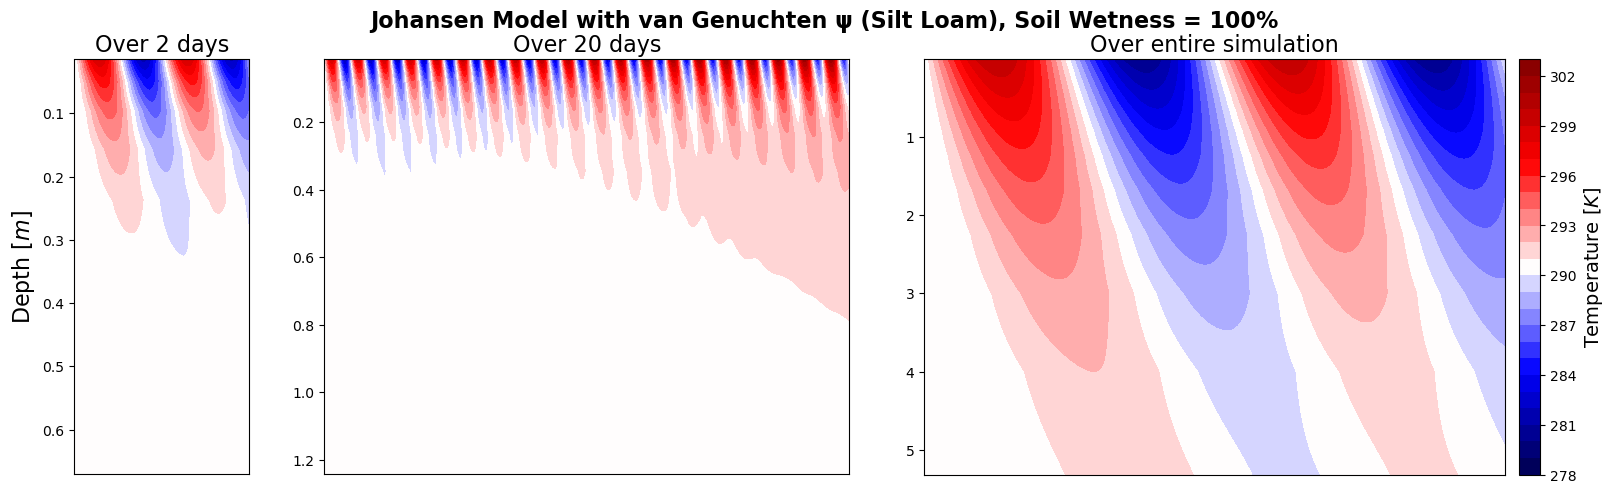

In [4]:
##################################################
##################################################
timestep = 600       # Model time step in seconds
days_to_run = 730    # How many days to run the model

#soil_type = "Sand"
#soil_type = "Loamy Sand"
#soil_type = "Sandy Loam"
soil_type = "Silt Loam"
#soil_type = "Loam"
#soil_type = "Sandy Clay Loam"
#soil_type = "Silty Clay Loam"
#soil_type = "Clay Loam"
#soil_type = "Sandy Clay"
#soil_type = "Silty Clay"
#soil_type = "Clay"

case = "Joh" ; t_model_type = "Johansen"
#case = "M&P" ; t_model_type = "McCumber & Pielke"

#param_psi = 'C&H' ;  psi_type = "Clapp & Hornberger"
param_psi = 'vG' ; psi_type = "van Genuchten"

# Initialize soil column
swi        = 1.00  # Value for soil wetness index throughout column (fraction of saturation)
init_sfc_t = 290.0  # Surface (skin) temperature (tied to surface air temperature)

dicy_mag = 10  # Magnitude of the idealized diurnal cycle of temperature
ancy_mag = 10  # Magnitude of the idealized annual cycle of temperature
##################################################
##################################################

tsteps = days_to_run * int(86400 / timestep)           

# Run the soil temperature model
sfc_t_series,soil_t_series = run_soil_heat_model(timestep,days_to_run,layer_thick,swi,init_sfc_t,
                                            param_psi=param_psi,param_h=case,dicy_mag=dicy_mag,ancy_mag=ancy_mag)

# Create a 24-hour mean for the big plot - to smooth out the diurnal jaggies
soil_dimean = moving_average(soil_t_series,int(86400/timestep))

t_dicy_0 = 0
#t_dicy_0 = 183 * int(86400 / timestep) # To shift the start date of the plot
d_ax1 = 2  # days for the first panel to span
d_ax2 = 20 # days for the second panel to span
y_ax1 = layer_mid[:8]
y_ax2 = layer_mid[:10]
y_ax3 = layer_mid

# Three plots - spanning, in order, `d_ax1` days, `d_ax2` days, and the entire simulation
fig, (ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(20, 5),gridspec_kw={'width_ratios': [1,3,4]})
plt.subplots_adjust(bottom=0.05,wspace=0.16)
im1 = ax1.contourf(np.arange(tsteps)[t_dicy_0:t_dicy_0+int(d_ax1*86400/timestep)],
                   y_ax1,soil_t_series[:8,t_dicy_0:t_dicy_0+int(d_ax1*86400/timestep)],
                   np.arange(278,304,1),cmap="seismic")
im2 = ax2.contourf(np.arange(tsteps)[t_dicy_0:t_dicy_0+int(d_ax2*86400/timestep)],
                   y_ax2,soil_t_series[:10,t_dicy_0:t_dicy_0+int(d_ax2*86400/timestep)],
                   np.arange(278,304,1),cmap="seismic")
im3 = ax3.contourf(np.arange(tsteps)[:soil_dimean.shape[1]],y_ax3,soil_dimean,np.arange(278,304,1),cmap="seismic")

ax1.invert_yaxis()
ax2.invert_yaxis()
ax3.invert_yaxis()

fig.colorbar(im3,ax=ax3,pad=0.02,format="%g").set_label(label="Temperature [$K$]",size=14)
ax1.set_title("Over "+str(d_ax1)+" days",fontsize=16)
ax1.set_ylabel("Depth [$m$]",fontsize=16)
ax1.set_xticks([])
ax1.set_xticklabels([]) 
ax2.set_title("Over "+str(d_ax2)+" days",fontsize=16)
ax2.set_xticks([])
ax2.set_xticklabels([]) 
ax3.set_title("Over entire simulation",fontsize=16)
ax3.set_xticks([])
ax3.set_xticklabels([]) ;
fig.suptitle(f"{t_model_type} Model with {psi_type} ψ ({soil_type}), Soil Wetness = {swi:.0%}",
             fontsize=16,fontweight='bold') ;

Paste a copy of the model cell below and rerun, changing `swi` to 0.0 

Running for 105120 time steps.
|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........* * * DONE!


Text(0.5, 0.98, 'Johansen Model with van Genuchten ψ (Silt Loam), Soil Wetness = 0%')

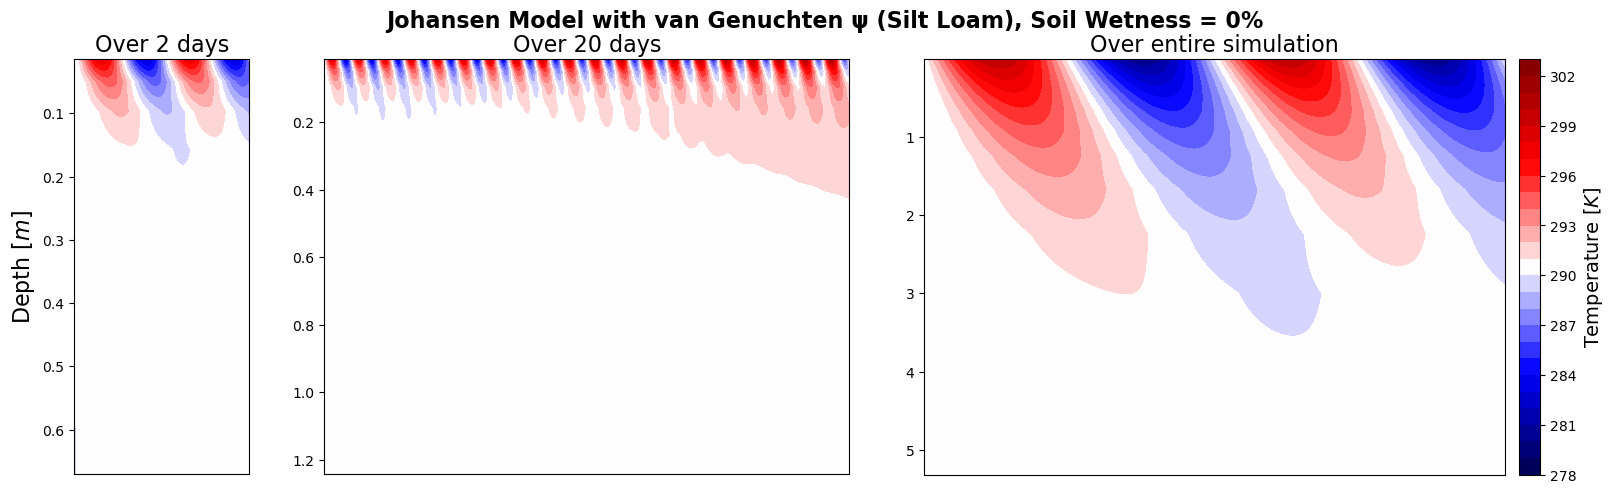

In [5]:
##################################################
##################################################
timestep = 600       # Model time step in seconds
days_to_run = 730    # How many days to run the model

#soil_type = "Sand"
#soil_type = "Loamy Sand"
#soil_type = "Sandy Loam"
soil_type = "Silt Loam"
#soil_type = "Loam"
#soil_type = "Sandy Clay Loam"
#soil_type = "Silty Clay Loam"
#soil_type = "Clay Loam"
#soil_type = "Sandy Clay"
#soil_type = "Silty Clay"
#soil_type = "Clay"

case = "Joh" ; t_model_type = "Johansen"
#case = "M&P" ; t_model_type = "McCumber & Pielke"

#param_psi = 'C&H' ;  psi_type = "Clapp & Hornberger"
param_psi = 'vG' ; psi_type = "van Genuchten"

# Initialize soil column
swi        = 0.0  # Value for soil wetness index throughout column (fraction of saturation)
init_sfc_t = 290.0  # Surface (skin) temperature (tied to surface air temperature)

dicy_mag = 10  # Magnitude of the idealized diurnal cycle of temperature
ancy_mag = 10  # Magnitude of the idealized annual cycle of temperature
##################################################
##################################################

tsteps = days_to_run * int(86400 / timestep)           

# Run the soil temperature model
sfc_t_series,soil_t_series = run_soil_heat_model(timestep,days_to_run,layer_thick,swi,init_sfc_t,
                                            param_psi=param_psi,param_h=case,dicy_mag=dicy_mag,ancy_mag=ancy_mag)

# Create a 24-hour mean for the big plot - to smooth out the diurnal jaggies
soil_dimean = moving_average(soil_t_series,int(86400/timestep))

t_dicy_0 = 0
#t_dicy_0 = 183 * int(86400 / timestep) # To shift the start date of the plot
d_ax1 = 2  # days for the first panel to span
d_ax2 = 20 # days for the second panel to span
y_ax1 = layer_mid[:8]
y_ax2 = layer_mid[:10]
y_ax3 = layer_mid

# Three plots - spanning, in order, `d_ax1` days, `d_ax2` days, and the entire simulation
fig, (ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(20, 5),gridspec_kw={'width_ratios': [1,3,4]})
plt.subplots_adjust(bottom=0.05,wspace=0.16)
im1 = ax1.contourf(np.arange(tsteps)[t_dicy_0:t_dicy_0+int(d_ax1*86400/timestep)],
                   y_ax1,soil_t_series[:8,t_dicy_0:t_dicy_0+int(d_ax1*86400/timestep)],
                   np.arange(278,304,1),cmap="seismic")
im2 = ax2.contourf(np.arange(tsteps)[t_dicy_0:t_dicy_0+int(d_ax2*86400/timestep)],
                   y_ax2,soil_t_series[:10,t_dicy_0:t_dicy_0+int(d_ax2*86400/timestep)],
                   np.arange(278,304,1),cmap="seismic")
im3 = ax3.contourf(np.arange(tsteps)[:soil_dimean.shape[1]],y_ax3,soil_dimean,np.arange(278,304,1),cmap="seismic")

ax1.invert_yaxis()
ax2.invert_yaxis()
ax3.invert_yaxis()

fig.colorbar(im3,ax=ax3,pad=0.02,format="%g").set_label(label="Temperature [$K$]",size=14)
ax1.set_title("Over "+str(d_ax1)+" days",fontsize=16)
ax1.set_ylabel("Depth [$m$]",fontsize=16)
ax1.set_xticks([])
ax1.set_xticklabels([]) 
ax2.set_title("Over "+str(d_ax2)+" days",fontsize=16)
ax2.set_xticks([])
ax2.set_xticklabels([]) 
ax3.set_title("Over entire simulation",fontsize=16)
ax3.set_xticks([])
ax3.set_xticklabels([]) ;
fig.suptitle(f"{t_model_type} Model with {psi_type} ψ ({soil_type}), Soil Wetness = {swi:.0%}",
             fontsize=16,fontweight='bold')

Our simple model has an annual cycle of surface temperature that varies as a sine wave ±10˚ from a climatological mean temperature of 290 K - our initial surface temperature. There is also a sine wave for the diurnal cycle of temperature superimposed that also has an amplitude of ±10˚ between day and night. The dirunal cycle is apparent in the first two panels, the annual cycle is clear in the panel on the right (notice the depth scales are different in each plot).

### Answer some questions

1. Describe what is fundamentally different between the diurnal and seasonal cycles of temperature in the soil. Why do you think this is so? What must be happening physically to cause the differences?
2. In both the daily and the annual cycle of temperature, there is also a fundamental difference between the signals in the saturated case and the completely dry case. What is the difference, and why? 
3. If (in 10-15 years when you are rich and famous) you wanted to build a wine cellar under one of your many *chateaus*, deep enough that the temperature would fluctuate no more than ±1˚C throughout the year. How deep would you have to dig down at your chateau outside Los Angeles (dry soil)? At your chateau near Seattle (wet soil)?

### Answers (A)

1. Diurnal temperatures penetrate the soil much more shallowly (0.2-0.3 m) than seasonal temperatures (3.5 - more than 5 m). The seasonal temperatures include all the diurnal temperature fluctuations, and since they're measured a over longer time period, the temperatures penetrate deeper/further into the soil.  

2. The temperatures in both the diurnal and annual plots penetrate the soil much deeper in the saturated soil (over 0.3 and over 5 m) than in the dry soil (nearly 0.2 and around 3.5 m). This is due to the thermal conductivity differences between wet and dry soils. In dry soil, the air between the soil grains acts as an insulator that slows temperature propagation, while in wet soil, water takes the place of air within the soil. Although water does increase the heat capacity of the soil, it increases its conductivity much more, causing the diffusivity to increase -- seen with the deeper temperature penetration and the steeper slope of the plots in the saturated soil plots. 

3. In a dry soil location, we would need to dig at least 4m below the surface to limit temperature flucuations to around ±1˚C, while in a wet soil location, we would need to dig much deeper - probably further than 6-8 m - for the same stability. 


--------------------

## Part B. Soil Temperature and Soil Type

Make two copies below of the code cell for the totally dry soil simulation above. In one, set the soil type to "Sand" and in the other "Silty Clay Loam". Run them each.

Running for 105120 time steps.
|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........* * * DONE!


Text(0.5, 0.98, 'Johansen Model with van Genuchten ψ (Sand), Soil Wetness = 0%')

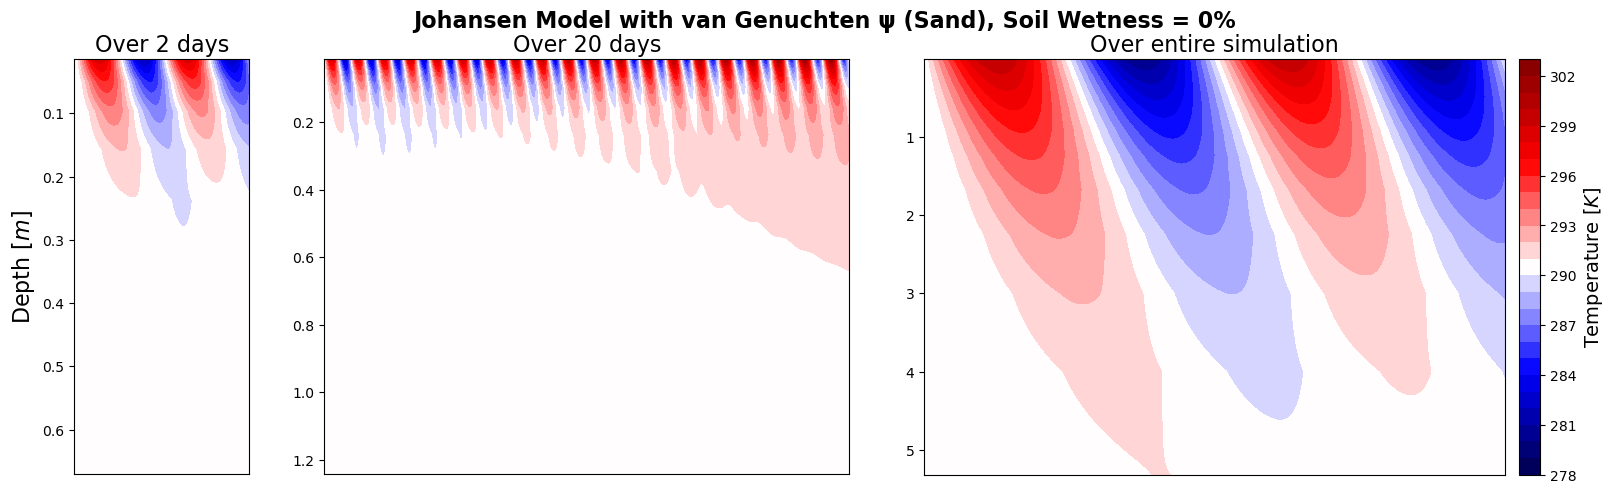

In [6]:
##################################################
##################################################
timestep = 600       # Model time step in seconds
days_to_run = 730    # How many days to run the model

soil_type = "Sand"
#soil_type = "Loamy Sand"
#soil_type = "Sandy Loam"
# soil_type = "Silt Loam"
#soil_type = "Loam"
#soil_type = "Sandy Clay Loam"
#soil_type = "Silty Clay Loam"
#soil_type = "Clay Loam"
#soil_type = "Sandy Clay"
#soil_type = "Silty Clay"
#soil_type = "Clay"

case = "Joh" ; t_model_type = "Johansen"
#case = "M&P" ; t_model_type = "McCumber & Pielke"

#param_psi = 'C&H' ;  psi_type = "Clapp & Hornberger"
param_psi = 'vG' ; psi_type = "van Genuchten"

# Initialize soil column
swi        = 0.0  # Value for soil wetness index throughout column (fraction of saturation)
init_sfc_t = 290.0  # Surface (skin) temperature (tied to surface air temperature)

dicy_mag = 10  # Magnitude of the idealized diurnal cycle of temperature
ancy_mag = 10  # Magnitude of the idealized annual cycle of temperature
##################################################
##################################################

tsteps = days_to_run * int(86400 / timestep)           

# Run the soil temperature model
sfc_t_series,soil_t_series = run_soil_heat_model(timestep,days_to_run,layer_thick,swi,init_sfc_t,
                                            param_psi=param_psi,param_h=case,dicy_mag=dicy_mag,ancy_mag=ancy_mag)

# Create a 24-hour mean for the big plot - to smooth out the diurnal jaggies
soil_dimean = moving_average(soil_t_series,int(86400/timestep))

t_dicy_0 = 0
#t_dicy_0 = 183 * int(86400 / timestep) # To shift the start date of the plot
d_ax1 = 2  # days for the first panel to span
d_ax2 = 20 # days for the second panel to span
y_ax1 = layer_mid[:8]
y_ax2 = layer_mid[:10]
y_ax3 = layer_mid

# Three plots - spanning, in order, `d_ax1` days, `d_ax2` days, and the entire simulation
fig, (ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(20, 5),gridspec_kw={'width_ratios': [1,3,4]})
plt.subplots_adjust(bottom=0.05,wspace=0.16)
im1 = ax1.contourf(np.arange(tsteps)[t_dicy_0:t_dicy_0+int(d_ax1*86400/timestep)],
                   y_ax1,soil_t_series[:8,t_dicy_0:t_dicy_0+int(d_ax1*86400/timestep)],
                   np.arange(278,304,1),cmap="seismic")
im2 = ax2.contourf(np.arange(tsteps)[t_dicy_0:t_dicy_0+int(d_ax2*86400/timestep)],
                   y_ax2,soil_t_series[:10,t_dicy_0:t_dicy_0+int(d_ax2*86400/timestep)],
                   np.arange(278,304,1),cmap="seismic")
im3 = ax3.contourf(np.arange(tsteps)[:soil_dimean.shape[1]],y_ax3,soil_dimean,np.arange(278,304,1),cmap="seismic")

ax1.invert_yaxis()
ax2.invert_yaxis()
ax3.invert_yaxis()

fig.colorbar(im3,ax=ax3,pad=0.02,format="%g").set_label(label="Temperature [$K$]",size=14)
ax1.set_title("Over "+str(d_ax1)+" days",fontsize=16)
ax1.set_ylabel("Depth [$m$]",fontsize=16)
ax1.set_xticks([])
ax1.set_xticklabels([]) 
ax2.set_title("Over "+str(d_ax2)+" days",fontsize=16)
ax2.set_xticks([])
ax2.set_xticklabels([]) 
ax3.set_title("Over entire simulation",fontsize=16)
ax3.set_xticks([])
ax3.set_xticklabels([]) ;
fig.suptitle(f"{t_model_type} Model with {psi_type} ψ ({soil_type}), Soil Wetness = {swi:.0%}",
             fontsize=16,fontweight='bold')

Running for 105120 time steps.
|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|.........* * * DONE!


Text(0.5, 0.98, 'Johansen Model with van Genuchten ψ (Silty Clay Loam), Soil Wetness = 0%')

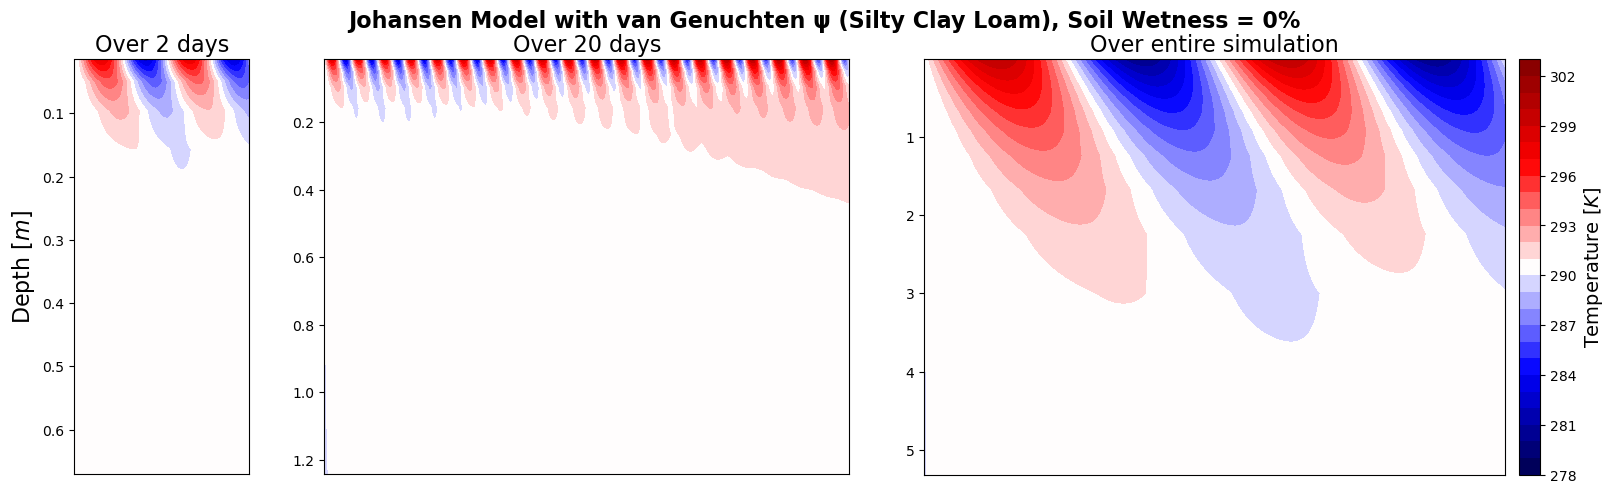

In [7]:
##################################################
##################################################
timestep = 600       # Model time step in seconds
days_to_run = 730    # How many days to run the model

#soil_type = "Sand"
#soil_type = "Loamy Sand"
#soil_type = "Sandy Loam"
# soil_type = "Silt Loam"
#soil_type = "Loam"
#soil_type = "Sandy Clay Loam"
soil_type = "Silty Clay Loam"
#soil_type = "Clay Loam"
#soil_type = "Sandy Clay"
#soil_type = "Silty Clay"
#soil_type = "Clay"

case = "Joh" ; t_model_type = "Johansen"
#case = "M&P" ; t_model_type = "McCumber & Pielke"

#param_psi = 'C&H' ;  psi_type = "Clapp & Hornberger"
param_psi = 'vG' ; psi_type = "van Genuchten"

# Initialize soil column
swi        = 0.0  # Value for soil wetness index throughout column (fraction of saturation)
init_sfc_t = 290.0  # Surface (skin) temperature (tied to surface air temperature)

dicy_mag = 10  # Magnitude of the idealized diurnal cycle of temperature
ancy_mag = 10  # Magnitude of the idealized annual cycle of temperature
##################################################
##################################################

tsteps = days_to_run * int(86400 / timestep)           

# Run the soil temperature model
sfc_t_series,soil_t_series = run_soil_heat_model(timestep,days_to_run,layer_thick,swi,init_sfc_t,
                                            param_psi=param_psi,param_h=case,dicy_mag=dicy_mag,ancy_mag=ancy_mag)

# Create a 24-hour mean for the big plot - to smooth out the diurnal jaggies
soil_dimean = moving_average(soil_t_series,int(86400/timestep))

t_dicy_0 = 0
#t_dicy_0 = 183 * int(86400 / timestep) # To shift the start date of the plot
d_ax1 = 2  # days for the first panel to span
d_ax2 = 20 # days for the second panel to span
y_ax1 = layer_mid[:8]
y_ax2 = layer_mid[:10]
y_ax3 = layer_mid

# Three plots - spanning, in order, `d_ax1` days, `d_ax2` days, and the entire simulation
fig, (ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(20, 5),gridspec_kw={'width_ratios': [1,3,4]})
plt.subplots_adjust(bottom=0.05,wspace=0.16)
im1 = ax1.contourf(np.arange(tsteps)[t_dicy_0:t_dicy_0+int(d_ax1*86400/timestep)],
                   y_ax1,soil_t_series[:8,t_dicy_0:t_dicy_0+int(d_ax1*86400/timestep)],
                   np.arange(278,304,1),cmap="seismic")
im2 = ax2.contourf(np.arange(tsteps)[t_dicy_0:t_dicy_0+int(d_ax2*86400/timestep)],
                   y_ax2,soil_t_series[:10,t_dicy_0:t_dicy_0+int(d_ax2*86400/timestep)],
                   np.arange(278,304,1),cmap="seismic")
im3 = ax3.contourf(np.arange(tsteps)[:soil_dimean.shape[1]],y_ax3,soil_dimean,np.arange(278,304,1),cmap="seismic")

ax1.invert_yaxis()
ax2.invert_yaxis()
ax3.invert_yaxis()

fig.colorbar(im3,ax=ax3,pad=0.02,format="%g").set_label(label="Temperature [$K$]",size=14)
ax1.set_title("Over "+str(d_ax1)+" days",fontsize=16)
ax1.set_ylabel("Depth [$m$]",fontsize=16)
ax1.set_xticks([])
ax1.set_xticklabels([]) 
ax2.set_title("Over "+str(d_ax2)+" days",fontsize=16)
ax2.set_xticks([])
ax2.set_xticklabels([]) 
ax3.set_title("Over entire simulation",fontsize=16)
ax3.set_xticks([])
ax3.set_xticklabels([]) ;
fig.suptitle(f"{t_model_type} Model with {psi_type} ψ ({soil_type}), Soil Wetness = {swi:.0%}",
             fontsize=16,fontweight='bold')

### Answer some questions

1. Which soil type conducts heat more deeply below the surface? Why? (consider the compositions - you should have a peek at the Pandas DataFrame `texture_table` for some clues)

2. How deep would you have to dig for your wine cellar at your beach chateau (built on sand)? Your chateau in the hills (built on silty clay loam)?

### Answers (B)

1. The sand soil conducts heat more deeply below the surface (up to over 5m seasonally compared to less than 4m for silty clay loam). The sand soil has a mineral composition of 92% quartz, according to the `texture_table`, while the silty clay loam has only 10% quartz. Since quartz has much higher thermal conducticity compared to clay, the outsized composition of quartz in sand results in deeper temperature conductivity (even with the tighter packing of clay particles in silty clay loam).

2. Similar to Part A, we would need to dig to very different depths for these cellars: over 6-8 m for a sandy beach cellar and closer to 4-5 m for a cellar in the hills. 


In [8]:
texture_table

,19,BB,DRYSMC,F11,MAXSMC,REFSMC,SATPSI,SATDK,SATDW,WLTSMC,QTZ,VG_SAT,VG_A,VG_N,VG_SATDK
STAS-RUC,,,,,,,,,,,,,,,
Sand,1,4.05,0.045,1.47,0.395,0.236,0.121,1.760000e-04,6.080000e-07,0.068,0.92,0.43,0.145,2.68,8.250000e-05
Loamy Sand,2,4.38,0.057,1.41,0.410,0.383,0.090,1.560000e-04,5.140000e-06,0.075,0.82,0.41,0.124,2.28,4.050000e-05
Sandy Loam,3,4.90,0.065,1.34,0.435,0.383,0.218,3.470000e-05,8.050000e-06,0.114,0.60,0.41,0.075,1.89,1.230000e-05
Silt Loam,4,5.30,0.067,1.27,0.485,0.360,0.786,7.200000e-06,2.390000e-05,0.179,0.25,0.45,0.020,1.41,1.250000e-06
Silt,5,5.30,0.034,1.27,0.485,0.383,0.786,7.200000e-06,2.390000e-05,0.179,0.10,0.45,0.020,1.41,1.250000e-06
Loam,6,5.39,0.078,1.21,0.451,0.329,0.478,6.950000e-06,1.430000e-05,0.155,0.40,0.43,0.036,1.56,2.890000e-06
Sandy Clay Loam,7,7.12,0.100,1.18,0.420,0.314,0.299,6.300000e-06,9.900000e-06,0.175,0.60,0.39,0.059,1.48,3.640000e-06
Silty Clay Loam,8,7.75,0.089,1.32,0.477,0.387,0.356,1.700000e-06,2.370000e-05,0.218,0.10,0.43,0.010,1.23,1.940000e-07
Clay Loam,9,8.52,0.095,1.23,0.476,0.382,0.630,2.450000e-06,1.130000e-05,0.250,0.35,0.41,0.019,1.31,7.220000e-07


-------------------
-------------------

## <u>Soil Water Simulations</u>

The water mass balance in any vertical interval $dz$ in the soil:

$$
dz\;\dfrac{d\vartheta}{dt} = q_i - q_o - s
$$

Water flux in the vertical soil column:

$$
q=-k\;\dfrac{d(\psi + z)}{dz} = -k\;(\dfrac{d \psi}{dz} + 1),\; s = 0
$$

In finite difference form between two discrete layers $i$ and $i+1$:

$$
\quad q_{i+\frac{1}{2}} = -k_{i+\frac{1}{2}} \bigg(\dfrac{\psi_i - \psi_{i+1}}{\Delta z_{i,i+1}} + 1 \bigg)
$$

This function follows the formulation presented in Table 8.5 of *Bonan* (2019; "Climate Change and Terrestrial Ecosystem Modeling")

For soil water simulations, in addition to setting the `soil_type` and choosing the parameterization
for matric potential, we must set an initial soil moisture `init_swi` and choose a slope for the 
terrain `slope` that determines the rate of baseflow. A `slope=0` means no baseflow - a solid bottom underneath the soil column.

## Part C: Wetting Front

We will start with a relatively dry soil with no baseflow, prescribe a steady rain of about 1mm/hour, about an inch a day, and run for 10 days. This will allow us to visualize the "wetting front" development and progress from the soil surface downward. Run the code cell below for all the various soil types and notice the different progressions of the wetting front.

Running for 1440 time steps.
|.........
* * * DONE!


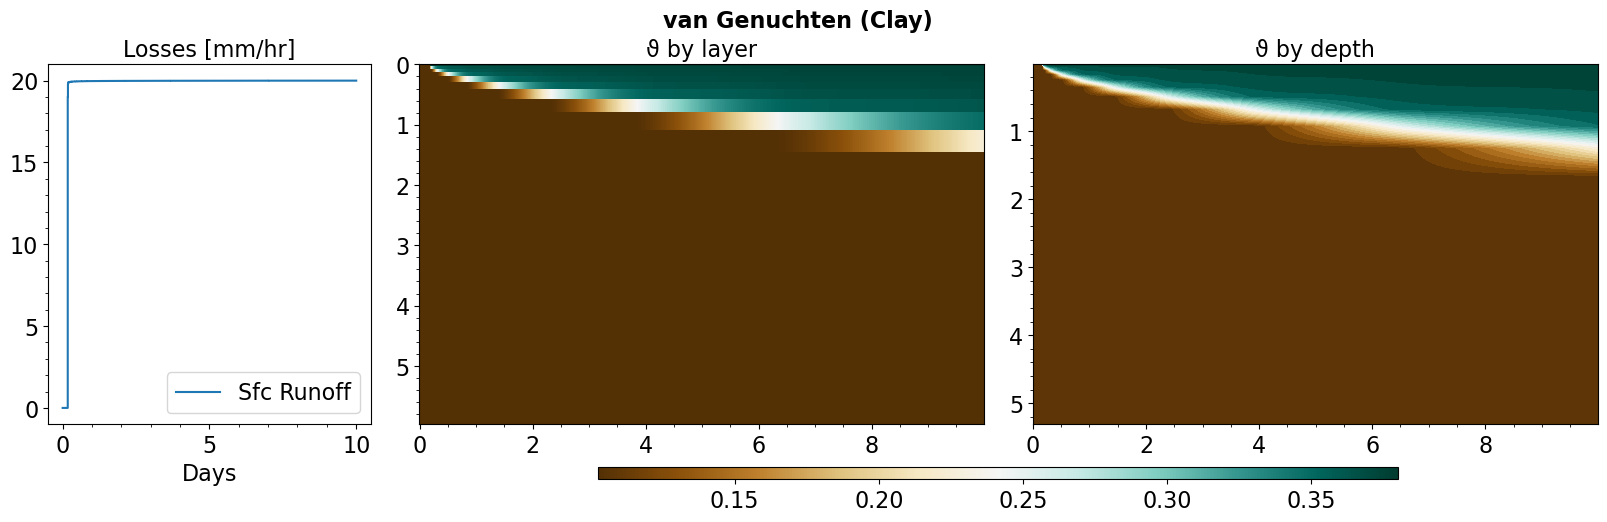

In [9]:
##################################################
##################################################
timestep = 600       # Model time step in seconds
days_to_run = 10     # How many days to run the model

slope=0.00           # Average slope of the terrain (for baseflow) [radians]

# soil_type = "Sand"
# soil_type = "Loamy Sand"
# soil_type = "Sandy Loam"
# soil_type = "Silt Loam"
# soil_type = "Loam"
# soil_type = "Sandy Clay Loam"
# soil_type = "Silty Clay Loam"
# soil_type = "Clay Loam"
# soil_type = "Sandy Clay"
# soil_type = "Silty Clay"
soil_type = "Clay"

#param_psi = 'C&H' ;  psi_type = "Clapp & Hornberger"
param_psi = 'vG' ; psi_type = "van Genuchten"

# Initialize soil column
init_swi   = 0.27    # Initial value for soil wetness index throughout column (fraction of saturation)

# Add rain
rain_rate  = 5.56e-3 # [kg/m^2/s] -- About 20mm per hour 
#rain_rate  = 2.78e-5 # [kg/m^2/s] -- About 1mm per hour 

##################################################
##################################################

tsteps = days_to_run * int(86400 / timestep)           

# Run the soil moisture model
soil_w_series,qsb_series,qs_series,esoil_series,tveg_series,imbal_series = run_soil_water_model(timestep,
                       days_to_run,layer_thick,init_swi,param_psi=param_psi,slope=slope,rain_rate=rain_rate)

ss0 = soil_w_series
x_days = np.arange(tsteps+1)*timestep/86400

fig, (ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(20,5),gridspec_kw={'width_ratios': [4,7,7]})
plt.subplots_adjust(bottom=0.15,top=0.87,wspace=0.10)

ax1.step(x_days,qs_series*3600,label="Sfc Runoff")
#ax1.set_yscale('log')
ax1.set_title("Losses [mm/hr]",fontsize=16)
ax1.legend(fontsize=16)
ax1.tick_params('x',labelsize=16)
ax1.tick_params('y',labelsize=16)
ax1.xaxis.get_ticklocs(minor=True)
ax1.minorticks_on()
ax1.set_xlabel("Days",fontsize=16)

im2 = ax2.pcolormesh(x_days[:-1],layer_mid,ss0[:,:-1],cmap="BrBG",shading="auto")
ax2.set_title("ϑ by layer",fontsize=16)
ax2.invert_yaxis()
ax2.tick_params('x',labelsize=16)
ax2.tick_params('y',labelsize=16)
ax2.xaxis.get_ticklocs(minor=True)
ax2.minorticks_on()

im3 = ax3.contourf(x_days[:-1],layer_mid,ss0[:,:-1],32,cmap="BrBG")
ax3.set_title("ϑ by depth",fontsize=16)
ax3.invert_yaxis()
ax3.tick_params('x',labelsize=16)
ax3.tick_params('y',labelsize=16)
ax3.xaxis.get_ticklocs(minor=True)
ax3.minorticks_on()

cax = fig.add_axes([0.40, 0.04, 0.40, 0.025])
cbar = fig.colorbar(im2,cax=cax,orientation='horizontal')
cbar.ax.tick_params(labelsize=16)

fig.suptitle(f"{psi_type} ({soil_type})",fontsize=16,fontweight='bold') ;

### Rain rate = ~1 mm/hr (default)
<img src="../wf-sand.png" />
<img src="../wf-loamy-sand.png" />
<img src="../wf-sandy-loam.png" />
<img src="../wf-silt-loam.png" />
<img src="../wf-loam.png" />
<img src="../wf-sandy-clay-loam.png" />
<img src="../wf-silty-clay-loam.png" />
<img src="../wf-clay-loam.png" />
<img src="../wf-sandy-clay.png" />
<img src="../wf-silty-clay.png" />
<img src="../wf-clay.png" />

### Rain rate = ~0.01 mm/hr (lower)
<img src="../lr-sand.png" />
<!-- <img src="../lr-loamy-sand.png" />
<img src="../lr-sandy-loam.png" />
<img src="../lr-sandy-clay-loam.png" />
<img src="../lr-silty-clay-loam.png" />
<img src="../lr-clay-loam.png" />
<img src="../lr-sandy-clay.png" />
<img src="../lr-silty-clay.png" /> -->
<img src="../lr-clay.png" />

### Rain rate = ~20 mm/hr (higher)
<img src="../hr-sand.png" />
<!-- <img src="../hr-loamy-sand.png" />
<img src="../hr-sandy-loam.png" />
<img src="../hr-sandy-clay-loam.png" />
<img src="../hr-silty-clay-loam.png" />
<img src="../hr-clay-loam.png" />
<img src="../hr-sandy-clay.png" />
<img src="../hr-silty-clay.png" /> -->
<img src="../hr-clay.png" />

### Answer some questions

We show two versions of the Hovmöller diagrams - in the middle panel where you can clearly see the discrete soil layers, increasing in thickness with depth [m], and in the right panel soil moisture is plotted as a traditional contour plot. The left panel shows terms by which water is leaving the system.

**Pay attention to the colorbar values** - the colors will always range from brown to green, but the values of volumetric soil moisture may vary quite a bit between simulations!

1. Describe the range or wetting rates you see - what soils wet downward the fastest? Which resist water penetration into the soil? Are there differences in the surface runoff time series? For the sand soil case, identify the periods when there is infiltration excess (Hortonian flow) versus saturation excess (Dunne flow).

2. For sand and similarly coarse soils, there are two fronts - a wetting front where the soil transitions sharply from dry soil below to moderately wet soil above, and then a second front forms where soils transition from moderately wet above to very wet below. What is happening to create this second front?

3. Related to question 2, after 5 days or so, the sandy soils reach a steady-state, but the soil is not equally wet at all depths - the shallower soils are a bit drier than the deep soil. What is this state and why does it form this way?

4. Try changing the rain rate - considerably higher and lower - describe what you see for sand soils, and for clay soils.

### Answers (C)

1. Sand and loamy sand soils wet downward the fastest, with water reaching 5 m depth in 2-3 days. In contrast, clay (and silty clay and sandy clay) resist water penetration more, barely reaching 1 m depth even after 10 days of 1mm rain per day. We see a similar pattern in the runoff: clay (and high clay composition) soils have high runoff very quickly, with runoff rates nearly equaling the hourly rain rates over the first few days before matching rain rates. In sand and loamy sand soils, there are a few days of lower runoff (3-5 days of 0.6 - 0.8 mm/hr) and the runoff increases more gradually over the next few days (to about 0.8-1.0 mm/hr). For the sand soil, we can see the Hortonian flow when rain starts on the first day, where runoff jumps from 0 to nearly 0.6 mm/hr because the soil is dry at this point and doesn't allow infiltration due to the sudden advent of rainfall. Dunne flow occurs when the soil reaches saturation around day 3, and we see the surface runoff plot correspondingly increase rapidly from 0.6 mm/hr to about 0.8 mm/hr. 

2. The second front occurs in sandy and coarse soils when the top layers of the soil become saturated from rainfall faster than the water can propagate downward. Eventually the water does move downward, creating the second front we see. 

3. This state is the field capacity of the soil column; it is the profile of soil moisture in a state of equilibrium, where the downward pull of gravity is balanced by the capillary action of water rising from wetter (deeper) to drier (more shallow) soil. 

4. For both sand and clay soils with a lower rain rate of about 0.01 mm/hr, we see the soils are able to absorb all the water from the rainfall; surface runoff is 0 for all 10 days. However, the water penetrates much deeper in sand soil (nearly 3 m by day 10) while the clay soil doesn't allow the water to penetrate below 0.5 m by day 10. With much higher rain rates (about 20 mm/hr), the sand soil's Hovmöller diagrams look similar to the original rain rate of 1 mm/hr, reaching saturation around day 2 with a second wetting front. However, the surface runoff is much higher from day 1, starting only very slightly below the point of Dunne flow when saturation is reached on day 2. Similarly, the clay sand's Hovmöller diagrams look similar to those from the original rain rates, but the surface runoff almost immediately matches the rate of rainfall due to the high volume of rain and low infiltration rate of clay. 


## Part D: Soil Drydown - Baseflow

Next, we start with nearly saturated soil, turn off the rain, and set the terrain slope to a moderate value to enable drainage from the base of the soil column into the vadose zone. We have also extended the length of the simulation to 40 days so we can see what is happening with slower processes.

Run the model for various soil types.

Running for 5760 time steps.
|.........|.........|.........|.........
* * * DONE!


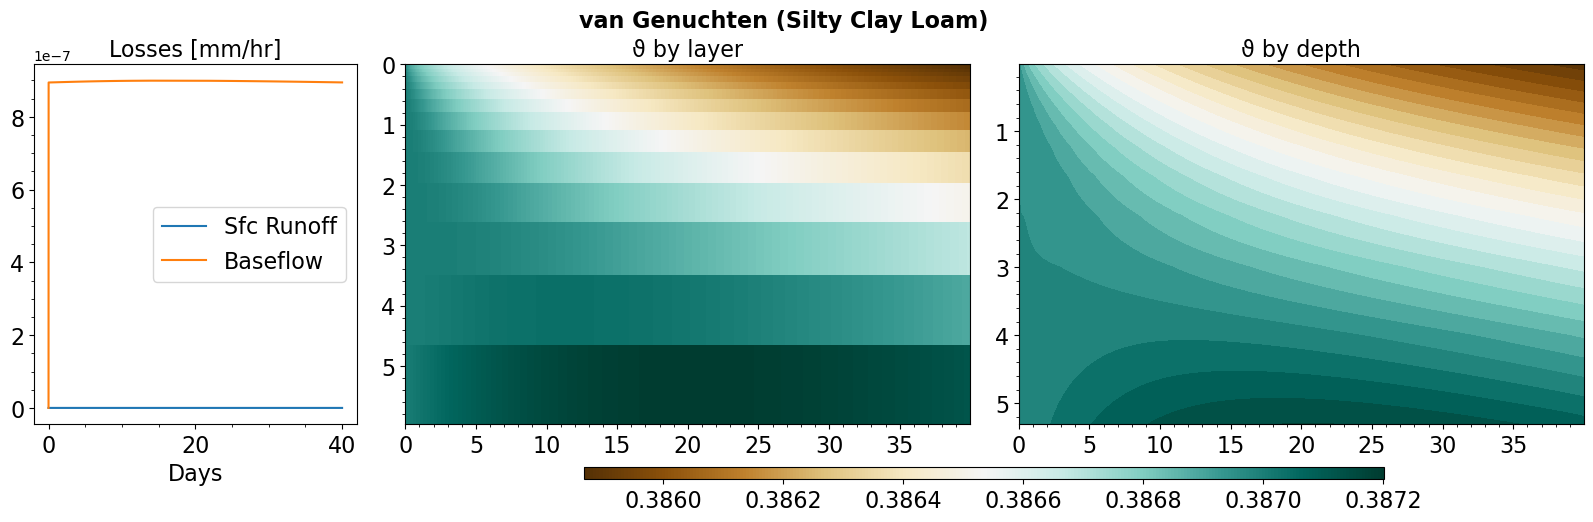

In [10]:
##################################################
##################################################
timestep = 600       # Model time step in seconds
days_to_run = 40     # How many days to run the model

slope=0.10           # Average slope of the terrain (for baseflow) [radians]

# soil_type = "Sand"
# soil_type = "Loamy Sand"
# soil_type = "Sandy Loam"
# soil_type = "Silt Loam"
# soil_type = "Loam"
# soil_type = "Sandy Clay Loam"
soil_type = "Silty Clay Loam"
# soil_type = "Clay Loam"
# soil_type = "Sandy Clay"
# soil_type = "Silty Clay"
# soil_type = "Clay"

#param_psi = 'C&H' ;  psi_type = "Clapp & Hornberger"
param_psi = 'vG' ; psi_type = "van Genuchten"

# Initialize soil column
init_swi   = 0.90    # Initial value for soil wetness index throughout column (fraction of saturation)

# No rain
rain_rate  = 0.0 # [kg/m^2/s] 
##################################################
##################################################

tsteps = days_to_run * int(86400 / timestep)           

# Run the soil moisture model
soil_w_series,qsb_series,qs_series,esoil_series,tveg_series,imbal_series = run_soil_water_model(timestep,
                       days_to_run,layer_thick,init_swi,param_psi=param_psi,slope=slope,rain_rate=rain_rate)

ss_b = soil_w_series
x_days = np.arange(tsteps+1)*timestep/86400

fig, (ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(20,5),gridspec_kw={'width_ratios': [4,7,7]})
plt.subplots_adjust(bottom=0.15,top=0.87,wspace=0.10)

ax1.step(x_days,qs_series*3600,label="Sfc Runoff")
ax1.step(x_days,qsb_series*3600,label="Baseflow")
#ax1.set_yscale('log')
ax1.set_title("Losses [mm/hr]",fontsize=16)
ax1.legend(fontsize=16)
ax1.tick_params('x',labelsize=16)
ax1.tick_params('y',labelsize=16)
ax1.xaxis.get_ticklocs(minor=True)
ax1.minorticks_on()
ax1.set_xlabel("Days",fontsize=16)

im2 = ax2.pcolormesh(x_days[:-1],layer_mid,ss_b[:,:-1],cmap="BrBG",shading="auto")
ax2.set_title("ϑ by layer",fontsize=16)
ax2.invert_yaxis()
ax2.tick_params('x',labelsize=16)
ax2.tick_params('y',labelsize=16)
ax2.xaxis.get_ticklocs(minor=True)
ax2.minorticks_on()

im3 = ax3.contourf(x_days[:-1],layer_mid,ss_b[:,:-1],32,cmap="BrBG")
ax3.set_title("ϑ by depth",fontsize=16)
ax3.invert_yaxis()
ax3.tick_params('x',labelsize=16)
ax3.tick_params('y',labelsize=16)
ax3.xaxis.get_ticklocs(minor=True)
ax3.minorticks_on()

cax = fig.add_axes([0.40, 0.04, 0.40, 0.025])
cbar = fig.colorbar(im2,cax=cax,orientation='horizontal')
cbar.ax.tick_params(labelsize=16)

fig.suptitle(f"{psi_type} ({soil_type})",fontsize=16,fontweight='bold') ;

<img src="../dd-sand.png" />
<img src="../dd-loamy-sand.png" />
<img src="../dd-sandy-loam.png" />
<img src="../dd-silt-loam.png" />
<img src="../dd-loam.png" />
<img src="../dd-sandy-clay-loam.png" />
<img src="../dd-silty-clay-loam.png" />
<img src="../dd-clay-loam.png" />
<img src="../dd-sandy-clay.png" />
<img src="../dd-silty-clay.png" />
<img src="../dd-clay.png" />

### Clay: 200 days
<img src="../clay-200.png" />

### Clay: slope 0.3
<img src="../clay-03.png" />

### Clay: slope 0.8
<img src="../clay-08.png" />


### Answer some questions

1. Describe the changes in the baseflow (maximum and evolution over time) as you change soil types from sand to silt to clay. Does this make sense, based on what you have learned about the different soil types?

2. The clay soils do not drain well. However, there is a redistribution of water within the soil column over time. Describe what happens and how it relates to field capacity.

3. For clay, try extending the simulation from 40 to 200 days - describe what you see. Then set it back to 40 days and try increasing the slope to 0.3 and 0.5 - describe what happens.


### Answers (D)

##### Note: the code had the original slope set to 0.5, so that's what all plots use (except the final two variations for the clay soil slopes of 0.3 and 0.8).

1. In sandy soils, we see the maximum baseflow rates spike early on (around 0.005 to 0.06 mm/hr) and decrease extremely rapidly. In silty soils, there is a similar initial spike (though to a much smaller value than sandy soils, up to around 0.00014 mm/hr), and a more gradual decline. In clay soils, the maximum baseflow rate is much smaller than both sandy and silty soils (around $3 \times 10^{-7}$ mm/hr) with a much, much slower decrease (almost a straight line). The ranges of the colorbars also vary quite drastically: from 0.40 to 0.10 for sand soil (wide range), 0.405 to 0.370 for silty loam (narrow-moderate range), and 0.3420 to 0.3418 for clay soil (very narrow range). This does make sense, as the sandy soils have larger, less compacted particles that allow water to drain quickly between them (high baseflow rate and maximum). Clay soils have a different physical composition and texture, described as flat, packed "jumbled playing cards", which causes the water to move incredibly slowly downward (low baseflow rate and maximum). Silty soils lie between these two extremes. 

2. As clay soils approach their vertical equilibrium profiles (field capacity), we see a similar pattern in the Hovmöller diagrams: drier at the top and bottom, but wetter in the middle of the column. This happens as the texture of the clay soils (which influences surface tension) prohibits the upward and downward movement of water past a certain point. Water does drain slowly down from the all layers of the column over time, and as the higher layers become drier, capillary action opposes the force of gravity. This results in the wetter mid-points of the soil columns: some of the water does drain out of the bottom but the water from the top doesn't get to reach the bottom before capillary action counteracts the downward movement. 

3. When running the model for 200 days instead of 40, we can see just how slowly the clay soil allows water to drain from it, with a steady but very slow baseflow rate causing the shift from relatively wetter to drier soil to take over 125 days. With a smaller slope of 0.3, we see a lower baseflow rate maximum (about $2 \times 10^{-7}$ mm/hr) and much slower rate decrease due to the less steep slope. With a higher slope of 0.8, we see a higher baseflow rate maximum (about $5 \times 10^{-7}$ mm/hr) and slightly higher baseflow rate increase, seen most clearly with the bottom layer becoming drier more quickly than the other layers. 


## Part E: Soil Drydown with Surface Evaporation

Next, we add in a parameterization for surface evaporation. It has a very simple idealized diurnal cycle, meant to simulate evaporation driven by available net radiation (daytime sunlight availability), but set to zero at "night".

Run the model for various soil types and observe the differences.

Running for 1440 time steps.
|.........
* * * DONE!


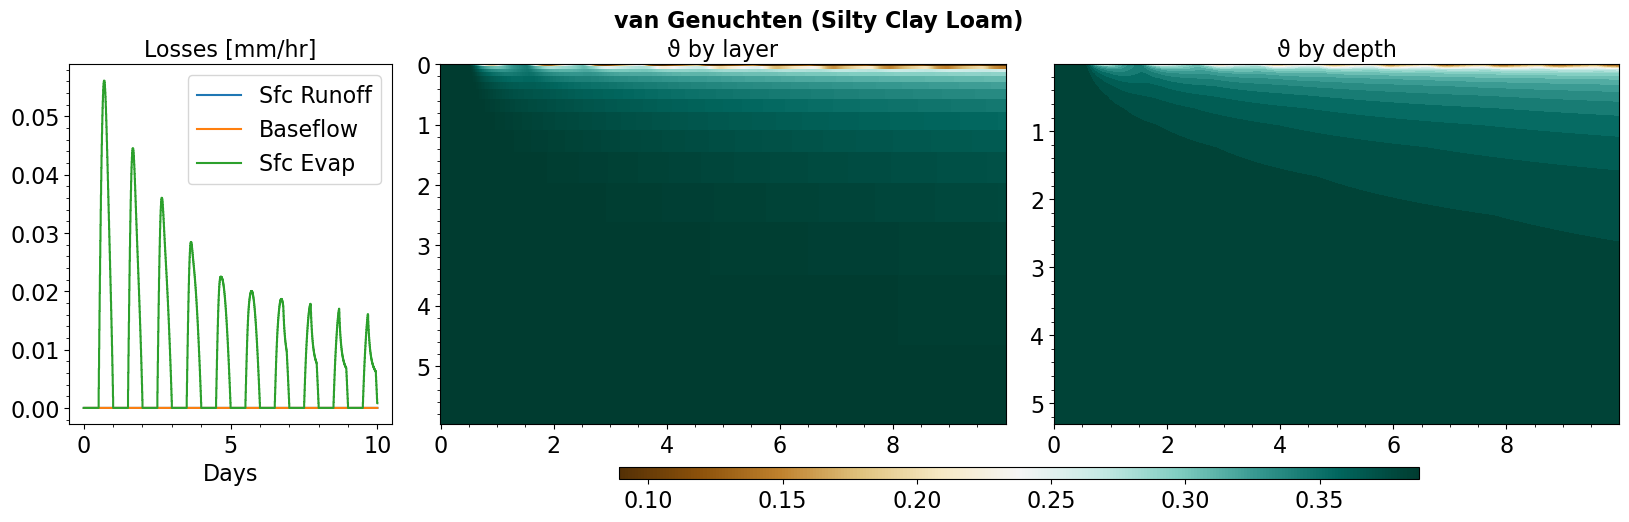

In [11]:
##################################################
##################################################
timestep = 600       # Model time step in seconds
days_to_run = 10     # How many days to run the model

slope = 0.10         # Average slope of the terrain (for baseflow) [radians]

# soil_type = "Sand"
# soil_type = "Loamy Sand"
# soil_type = "Sandy Loam"
# soil_type = "Silt Loam"
# soil_type = "Loam"
# soil_type = "Sandy Clay Loam"
soil_type = "Silty Clay Loam"
# soil_type = "Clay Loam"
# soil_type = "Sandy Clay"
# soil_type = "Silty Clay"
# soil_type = "Clay"

#param_psi = 'C&H' ;  psi_type = "Clapp & Hornberger"
param_psi = 'vG' ; psi_type = "van Genuchten"

# Initialize soil column
init_swi   = 0.90    # Initial value for soil wetness index throughout column (fraction of saturation)

# No rain
rain_rate  = 0.0 # [kg/m^2/s] 
peak_sfc_evap = 5.6e-5 # [kg/m^2/s] -- About 0.2 mm/h
##################################################
##################################################

tsteps = days_to_run * int(86400 / timestep)           

# Run the soil moisture model
soil_w_series,qsb_series,qs_series,esoil_series,tveg_series,imbal_series = run_soil_water_model(timestep,
                       days_to_run,layer_thick,init_swi,param_psi=param_psi,slope=slope,
                       peak_sfc_evap=peak_sfc_evap,rain_rate=rain_rate)

ss_s = soil_w_series
x_days = np.arange(tsteps+1)*timestep/86400

fig, (ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(20,5),gridspec_kw={'width_ratios': [4,7,7]})
plt.subplots_adjust(bottom=0.15,top=0.87,wspace=0.10)

ax1.step(x_days,qs_series*3600,label="Sfc Runoff")
ax1.step(x_days,qsb_series*3600,label="Baseflow")
ax1.step(x_days,esoil_series*3600,label="Sfc Evap")
#ax1.set_yscale('log')
ax1.set_title("Losses [mm/hr]",fontsize=16)
ax1.legend(fontsize=16)
ax1.tick_params('x',labelsize=16)
ax1.tick_params('y',labelsize=16)
ax1.xaxis.get_ticklocs(minor=True)
ax1.minorticks_on()
ax1.set_xlabel("Days",fontsize=16)

im2 = ax2.pcolormesh(x_days[:-1],layer_mid,ss_s[:,:-1],cmap="BrBG",shading="auto")
ax2.set_title("ϑ by layer",fontsize=16)
ax2.invert_yaxis()
ax2.tick_params('x',labelsize=16)
ax2.tick_params('y',labelsize=16)
ax2.xaxis.get_ticklocs(minor=True)
ax2.minorticks_on()

im3 = ax3.contourf(x_days[:-1],layer_mid,ss_s[:,:-1],32,cmap="BrBG")
ax3.set_title("ϑ by depth",fontsize=16)
ax3.invert_yaxis()
ax3.tick_params('x',labelsize=16)
ax3.tick_params('y',labelsize=16)
ax3.xaxis.get_ticklocs(minor=True)
ax3.minorticks_on()

cax = fig.add_axes([0.40, 0.04, 0.40, 0.025])
cbar = fig.colorbar(im2,cax=cax,orientation='horizontal')
cbar.ax.tick_params(labelsize=16)

fig.suptitle(f"{psi_type} ({soil_type})",fontsize=16,fontweight='bold') ;

<img src="../ev-sand.png" />
<img src="../ev-loamy-sand.png" />
<img src="../ev-sandy-loam.png" />
<img src="../ev-silt-loam.png" />
<img src="../ev-loam.png" />
<img src="../ev-sandy-clay-loam.png" />
<img src="../ev-silty-clay-loam.png" />
<img src="../ev-clay-loam.png" />
<img src="../ev-sandy-clay.png" />
<img src="../ev-silty-clay.png" />
<img src="../ev-clay.png" />

### Answer some questions

1. Notice the daily cycles of surface evaporation. The maximum rates are not for sand nor for clay - which soil allows for the greatest evaporation from the soil surface?  Why - what balance of factors must determine this?

2. For all but the high-clay soils, you can see the soil at the surface gets very dry each day (in the afternoon) but somehow gets wetter again each evening. There is no rainfall, and no dew (that would be a negative surface evaporation). What is happening?

### Answers (E)

1. The highest levels of daily evaporation are from silt loam and loam soils, each losing around 0.07 mm/hr on day 1 and down to about 0.05 mm/hr by day 10. This demonstrates a balance between the soils' water retention and hydraulic conductivity. Soils with more sand content will drain faster (i.e. they have lower water retention, seen with their higher baseflow rates), reducing the amount of moisture available near the surface to evaporate, leading to lower evaporation rates. Soils with more clay content have lower hydraulic conductivity which leads to lower evaporation rates as the water cannot move as easily to resupply evaporation at the surface. The loam and silt loam soils are in a sweet spot -- they have high enough conductivity to resupply the surface with water as it evaporates and high enough retention to prevent the water from draining away due to gravity. 

2. Solar radiation provides energy during the day -> increases evaporation -> peaks in the afternoon -> leads to drier surface soils -> causes strong vertical moisture gradient (drier at the top) -> sun sets -> evaporation stops/decreases dramatically -> surface soil stops drying -> existing gradient creates capillary action, bringing water up from the lower layers of the soil -> cycle repeats the next day


## Part F: Effect of Plant Transpiration.

We invoke a simple parameterization for daytime plant transpiration. It removes water from the soil proportionally to the vertical distribution of roots, which is determined by the parameter `root_beta`.

Running for 1440 time steps.
|.........
* * * DONE!


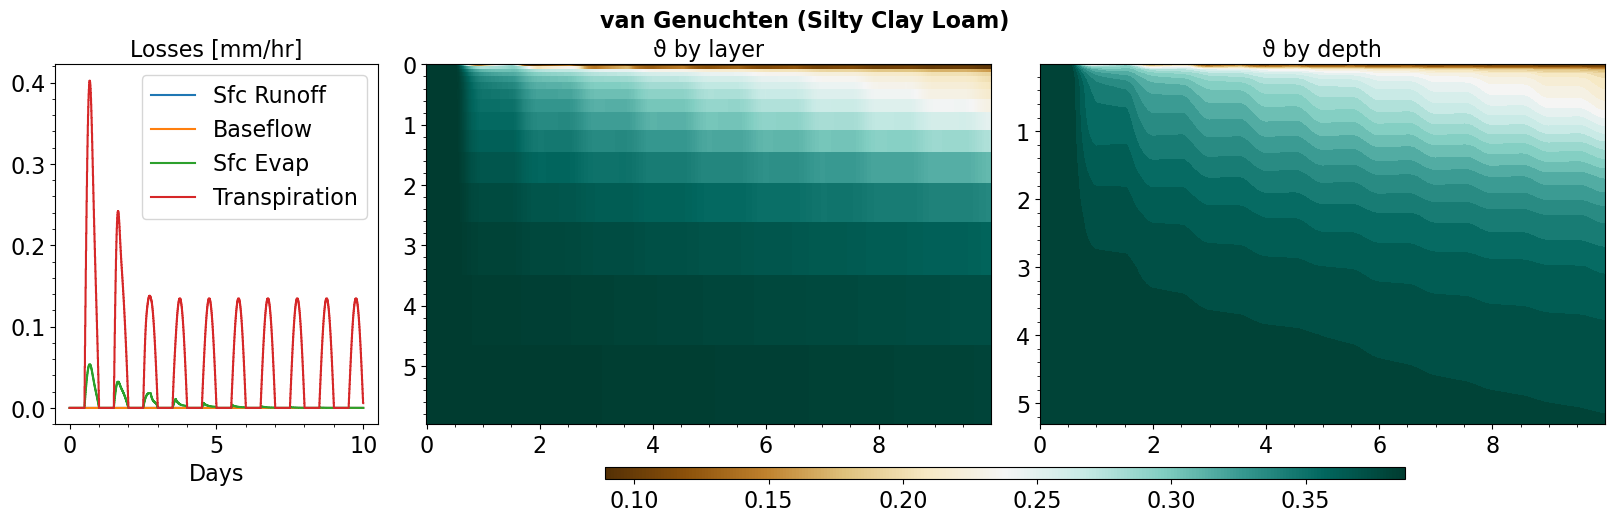

In [12]:
##################################################
##################################################
timestep = 600       # Model time step in seconds
days_to_run = 10     # How many days to run the model

slope = 0.10         # Average slope of the terrain (for baseflow) [radians]

# soil_type = "Sand"
# soil_type = "Loamy Sand"
# soil_type = "Sandy Loam"
# soil_type = "Silt Loam"
# soil_type = "Loam"
# soil_type = "Sandy Clay Loam"
soil_type = "Silty Clay Loam"
# soil_type = "Clay Loam"
# soil_type = "Sandy Clay"
# soil_type = "Silty Clay"
# soil_type = "Clay"

#param_psi = 'C&H' ;  psi_type = "Clapp & Hornberger"
param_psi = 'vG' ; psi_type = "van Genuchten"

# Initialize soil column
init_swi   = 0.90    # Initial value for soil wetness index throughout column (fraction of saturation)
root_beta  = 0.985    # Determines vertical distribution of roots in soil - where transpiration draws from

# No rain
rain_rate  = 0.0 # [kg/m^2/s] 
peak_sfc_evap = 5.6e-5 # [kg/m^2/s] -- About 0.2 mm/h
peak_transp   = 2.8e-5 # [kg/m^2/s] -- About 0.1 mm/h per layer
##################################################
##################################################

tsteps = days_to_run * int(86400 / timestep)           

# Run the soil moisture model
soil_w_series,qsb_series,qs_series,esoil_series,tveg_series,imbal_series = run_soil_water_model(timestep,
                       days_to_run,layer_thick,init_swi,param_psi=param_psi,slope=slope,root_beta=root_beta,
                       peak_sfc_evap=peak_sfc_evap,peak_transp=peak_transp,rain_rate=rain_rate)

ss_t = soil_w_series
x_days = np.arange(tsteps+1)*timestep/86400

fig, (ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(20,5),gridspec_kw={'width_ratios': [4,7,7]})
plt.subplots_adjust(bottom=0.15,top=0.87,wspace=0.10)

ax1.step(x_days,qs_series*3600,label="Sfc Runoff")
ax1.step(x_days,qsb_series*3600,label="Baseflow")
ax1.step(x_days,esoil_series*3600,label="Sfc Evap")
ax1.step(x_days,tveg_series*3600,label="Transpiration")

#ax1.set_yscale('log')
ax1.set_title("Losses [mm/hr]",fontsize=16)
ax1.legend(fontsize=16)
ax1.tick_params('x',labelsize=16)
ax1.tick_params('y',labelsize=16)
ax1.xaxis.get_ticklocs(minor=True)
ax1.minorticks_on()
ax1.set_xlabel("Days",fontsize=16)

im2 = ax2.pcolormesh(x_days[:-1],layer_mid,ss_t[:,:-1],cmap="BrBG",shading="auto")
ax2.set_title("ϑ by layer",fontsize=16)
ax2.invert_yaxis()
ax2.tick_params('x',labelsize=16)
ax2.tick_params('y',labelsize=16)
ax2.xaxis.get_ticklocs(minor=True)
ax2.minorticks_on()

im3 = ax3.contourf(x_days[:-1],layer_mid,ss_t[:,:-1],32,cmap="BrBG")
ax3.set_title("ϑ by depth",fontsize=16)
ax3.invert_yaxis()
ax3.tick_params('x',labelsize=16)
ax3.tick_params('y',labelsize=16)
ax3.xaxis.get_ticklocs(minor=True)
ax3.minorticks_on()

cax = fig.add_axes([0.40, 0.04, 0.40, 0.025])
cbar = fig.colorbar(im2,cax=cax,orientation='horizontal')
cbar.ax.tick_params(labelsize=16)

fig.suptitle(f"{psi_type} ({soil_type})",fontsize=16,fontweight='bold') ;

<img src="../pt-sand.png" />
<img src="../pt-loamy-sand.png" />
<img src="../pt-sandy-loam.png" />
<img src="../pt-silt-loam.png" />
<img src="../pt-loam.png" />
<img src="../pt-sandy-clay-loam.png" />
<img src="../pt-silty-clay-loam.png" />
<img src="../pt-clay-loam.png" />
<img src="../pt-sandy-clay.png" />
<img src="../pt-silty-clay.png" />
<img src="../pt-clay.png" />


### Answer some questions

1. Again for transpiration the maximum rates are not for sand nor for clay - which soil allows for the greatest transpiration?  How does this correspond to what we think of as "good" soil for plants, and why would such soils enable the most transpiration (meaning, also, the heartiest plant growth)?

There are a couple of extra code cells below:

2. In the first, try different values of `root_beta` and see how it affects the vertical profile of roots in the soil. Most of the *action* will be for values between 0.9 and 1. Describe how the profile changes.

3. The second cell plots differences between the results from Part D (baseflow), Part E (baseflow + surface evaporation) and Part F (baseflow + surface evaporation + transpiration). Go back and run each with Silty Clay Loam, and the same settings otherwise (`slope=0.10`, `init_swi=0.90`, same surface evaporation in E & F). Then run the cell below and describe the profiles and evolution of the differences in each plot, and why those patterns have arisen.

### Answers (F)

1. Again, loam and silt loam soils have the highest transpiration rates (both near 0.5 mm/hr). This corresponds directly with what is considered "good" soil for plants, as loam is defined as a mix of soil types having no more than 35-40% clay. These loamy soils enable the most transpiration due to their texture providing a large field capacity (good water retention) and enabling capillary action via plant roots (able to easily give up water). This allows plants to open their stomata for transpiration for longer periods of time without hitting water stress limits, allowing for more photosynthesis and thus more growth. 

2. From various plots with `root_beta` values between 0.9 and 0.99, we can see the fraction of root mass move from being concentrated above the top 1 m before dropping off sharply, to having the highest fraction of root mass around 1 m with some root mass above and below that point, with a more gradual decrease with depth. 

3. The "Impact of surface evaporation" plot shows that most of the moisture lost from evaporation alone is concentrated in the upper layer of soil (above 1 m) and is lost fairly quickly (reaching a steady level of dryness by day 2-3), while it also gradually causes the upper layers to become drier over the time period (some drying occurs between 1-2 m). The silty clay loam soil allows for capillary action to replenish the top layers of the soil each night after the daytime evaporation creates the moisture gradient, so the main evaporation effect is confined to the top-most layer. The "Impact of transpiration" plot shows that transpiration reduces the moisture in the soil at much deeper levels than just evaporation (with more dyring occuring between 1-2 m and some moderate drying up to 4 m as well), and more slowly (more drying occurs after day 7 with moderate drying in the earlier days). The "wiggles" seen in the plot correspond to transpiration only occuring during the day and stopping at night, while the depth of drying corresponds to the plant roots being able to access water from many depths and later release the moisture above the surface. 


Text(0.5, 0.98, 'Root beta: 0.999')

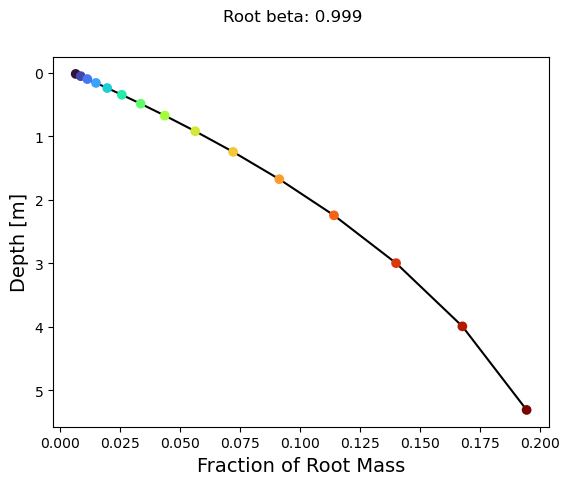

In [13]:
root_beta  = 0.999    # Determines vertical distribution of roots in soil - where transpiration draws from

roots = roots_jackson(layer_depth,root_beta=root_beta)
plt.plot(roots,layer_mid,c='k')
plt.scatter(roots,layer_mid,c=np.arange(nlayers),cmap='turbo',zorder=3)
plt.gca().invert_yaxis()
plt.ylabel("Depth [m]",fontsize=14)
plt.xlabel("Fraction of Root Mass",fontsize=14)
plt.suptitle(f"Root beta: {root_beta}")

<img src="./rb/rb-9.png" />
<img src="./rb/rb-91.png" />
<img src="./rb/rb-93.png" />
<img src="./rb/rb-95.png" />
<img src="./rb/rb-97.png" />
<img src="./rb/rb-99.png" />

Text(0.5, 0.98, 'van Genuchten (Silty Clay Loam)')

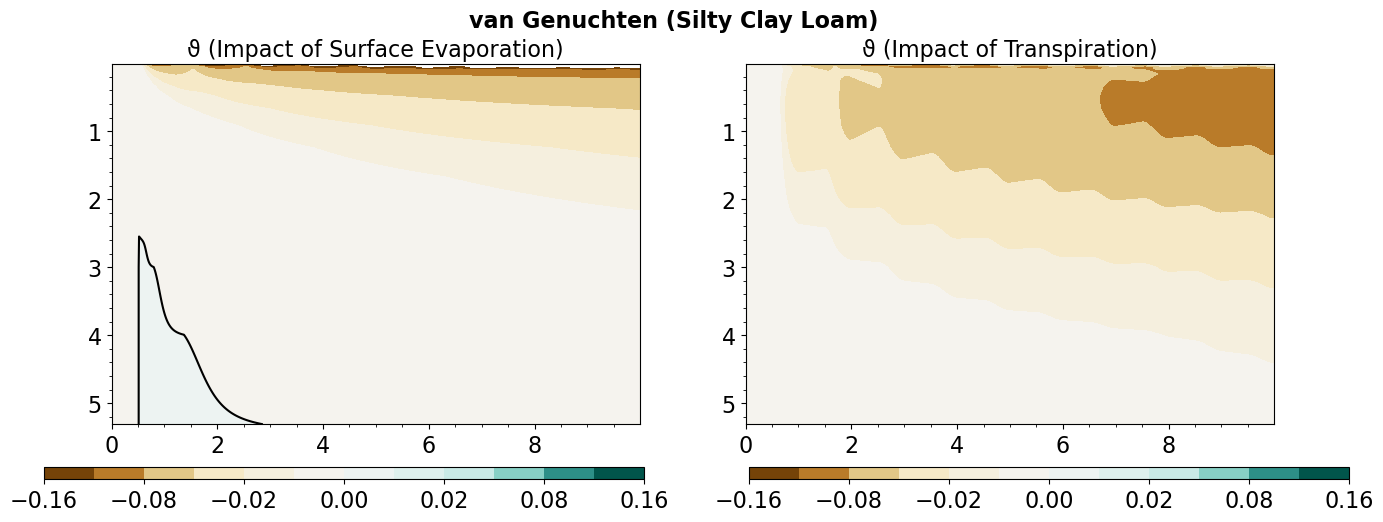

In [14]:
x_days = np.arange(tsteps)*timestep/86400

fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(15,5))
plt.subplots_adjust(bottom=0.15,top=0.87)

clevs = [-0.16,-0.12,-0.08,-0.04,-0.02,-0.01,0.0,0.01,0.02,0.04,0.08,0.12,0.16]

im1 = ax1.contourf(x_days,layer_mid,(ss_s[:,:tsteps]-ss_b[:,:tsteps]),clevs,cmap="BrBG")
ax1.contour(x_days,layer_mid,(ss_s[:,:tsteps]-ss_b[:,:tsteps]),[0.0],colors=['k'])
ax1.set_title("ϑ (Impact of Surface Evaporation)",fontsize=16)
ax1.invert_yaxis()
ax1.tick_params('x',labelsize=16)
ax1.tick_params('y',labelsize=16)
ax1.xaxis.get_ticklocs(minor=True)
ax1.minorticks_on()
cx1 = fig.add_axes([0.08, 0.04, 0.40, 0.025])
cb1 = fig.colorbar(im1,cax=cx1,orientation='horizontal')
cb1.ax.tick_params(labelsize=16)


im2 = ax2.contourf(x_days,layer_mid,(ss_t[:,:tsteps]-ss_s[:,:tsteps]),clevs,cmap="BrBG")
ax2.contour(x_days,layer_mid,(ss_t[:,:tsteps]-ss_s[:,:tsteps]),[0.0],colors=['k'])
ax2.set_title("ϑ (Impact of Transpiration)",fontsize=16)
ax2.invert_yaxis()
ax2.tick_params('x',labelsize=16)
ax2.tick_params('y',labelsize=16)
ax2.xaxis.get_ticklocs(minor=True)
ax2.minorticks_on()
cx2 = fig.add_axes([0.55, 0.04, 0.40, 0.025])
cb2 = fig.colorbar(im2,cax=cx2,orientation='horizontal')
cb2.ax.tick_params(labelsize=16)

fig.suptitle(f"{psi_type} ({soil_type})",fontsize=16,fontweight='bold')